# MSI Pipeline Exploration — Mahalanobis Similarity Index

**Project**: *Mahalanobis Similarity Index (MSI): A Novel Molecular Similarity Multivariate Framework*

**Authors**: Roberto Bernal-Jaquez, Elliot Ridout-Buhl, Emiliano Montoya, Leon Alday-Toledo, Felipe Aparicio — UAM Cuajimalpa

---

This notebook runs the **complete MSI pipeline fresh** using the restructured `msi.py` module across all four datasets. The goal is to reproduce and explore the key visualizations and metrics that characterize the MSI framework's behavior.

| Dataset | Reference | Source | Molecules | Purpose |
|---------|-----------|--------|----------:|---------|
| Aspirin | CC(=O)OC1=CC=CC=C1C(=O)O | ACI (PubChem) | ~31k | ACI case study |
| Ibuprofen | CC(C)CC1=CC=C(C=C1)C(C)C(=O)O | ACI (PubChem) | ~31k | Cross-reference comparison |
| Curcumin | O=C(/C=C/c1ccc(O)c(OC)c1)CC(=O)/C=C/c1ccc(O)c(OC)c1 | ACI (PubChem) | ~31k | Cross-reference comparison |
| QM9 Aniline | c1ccc(cc1)N | QM9 | ~127k | QM9 case study (with quantum properties) |

### Pipeline Steps (per dataset)
1. `generate_2d_vectors()` → PCA(300→30) + t-SNE(30→2) coordinates
2. `generate_300d_vectors()` → Mean mol2vec embeddings (300D)
3. `analyze_against_reference()` → $d_M$, $\theta_M$, TSI, molecular weight, etc.

### Visualizations

| # | Description | Dataset |
|---|-------------|---------|
| 1 | Reference molecule structures | Both |
| 2 | Top-10 analogs by $\theta_M$ (Mahalanobis angle) | ACI |
| 3 | Top-10 analogs by TSI (Tanimoto) | ACI |
| 4 | TSI vs $d_M$ and TSI vs $\theta_M$ scatter + LOWESS | ACI |
| 5 | 3D similarity map ($\theta_M$, $d_M$, TSI) | ACI |
| 6 | Polar representation ($\theta_M$, $d_M$) | ACI |
| 7 | Top-10 analogs by $\theta_M$ | QM9 |
| 8 | Top-10 analogs by TSI | QM9 |
| 9 | Ranking comparison: MSI ($\theta_M$) vs TSI | QM9 |
| 10 | TSI vs $d_M$ and TSI vs $\theta_M$ scatter + LOWESS | QM9 |
| 11 | Polar representation | QM9 |
| 12 | 3D: $\theta_M$ × $d_M$ × $E_{gap}$ | QM9 |
| 13 | Cross-reference comparison (all 3 ACI molecules) | ACI |

### Estimated Runtime
- ACI datasets (aspirin, ibuprofen, curcumin): ~25s each
- QM9 dataset: ~50s
- **Total**: ~2 minutes

---
## Section 0: Setup & Imports

In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# Import MSI pipeline
from gensim.models import Word2Vec
from msi import (
    generate_2d_vectors,
    generate_300d_vectors,
    analyze_against_reference,
)

sns.set_theme(style='white', font_scale=1.1)

# ---------------------------------------------------------------------------
# Paper methodology parameters (for reference)
# ---------------------------------------------------------------------------
PARAMS = {
    'regularization_lambda': 1e-5,
    'morgan_radius': 2,
    'morgan_nbits': 2048,
    'mol2vec_radius': 1,
    'pca_components': 30,
    'tsne_perplexity': 10,
    'tsne_iterations': 1000,
    'lowess_frac': 0.5,
}

print('Paper parameters:')
for k, v in PARAMS.items():
    print(f'  {k} = {v}')

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR = 'data'                            # Local dataset directory
OUTPUT_DIR = 'output_replication'            # Fresh pipeline outputs
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(DATA_DIR, 'model_300dim.pkl')
print(f'\nData directory:   {os.path.abspath(DATA_DIR)}')
print(f'Output directory: {os.path.abspath(OUTPUT_DIR)}')
print(f'Model path:       {os.path.abspath(MODEL_PATH)}')

Paper parameters:
  regularization_lambda = 1e-05
  morgan_radius = 2
  morgan_nbits = 2048
  mol2vec_radius = 1
  pca_components = 30
  tsne_perplexity = 10
  tsne_iterations = 1000
  lowess_frac = 0.5

Data directory:   /Users/nose/Desktop/MSI/data
Output directory: /Users/nose/Desktop/MSI/output_replication
Model path:       /Users/nose/Desktop/MSI/data/model_300dim.pkl


---
## Section 1: Load Mol2Vec Model

In [3]:
print('Loading mol2vec model...')
t0 = time.time()
model = Word2Vec.load(MODEL_PATH)
print(f'Model loaded in {time.time() - t0:.1f}s')
print(f'Vocabulary size: {len(model.wv):,} identifiers')
print(f'Vector dimensionality: {model.wv.vector_size}')

2026-02-24 09:20:22,789 - INFO - loading Word2Vec object from data/model_300dim.pkl


Loading mol2vec model...


2026-02-24 09:20:23,021 - INFO - loading wv recursively from data/model_300dim.pkl.wv.* with mmap=None
2026-02-24 09:20:23,022 - INFO - setting ignored attribute syn0norm to None
2026-02-24 09:20:23,094 - INFO - setting ignored attribute cum_table to None
2026-02-24 09:20:23,152 - INFO - Word2Vec lifecycle event {'fname': 'data/model_300dim.pkl', 'datetime': '2026-02-24T09:20:23.152730', 'gensim': '4.4.0', 'python': '3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-15.5-arm64-arm-64bit-Mach-O', 'event': 'loaded'}


Model loaded in 0.4s
Vocabulary size: 21,003 identifiers
Vector dimensionality: 300


### Helper functions

In [4]:
from PIL import Image as PILImage, ImageDraw, ImageFont


def mol_to_img(smiles, size=(250, 250)):
    """Convert SMILES to PIL image."""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Draw.MolToImage(mol, size=size)
    return None


def mol_grid(smiles_list, labels=None, mols_per_row=3, img_size=(300, 300)):
    """Build a molecule grid image as a numpy array using individual MolToImage calls.

    Avoids MolsToGridImage which has compatibility issues across RDKit versions.
    """
    n = len(smiles_list)
    legends = labels if labels else ['' for _ in smiles_list]
    n_rows = (n + mols_per_row - 1) // mols_per_row
    label_height = 50  # pixels for label text below each molecule

    cell_w = img_size[0]
    cell_h = img_size[1] + label_height
    canvas = PILImage.new('RGB', (mols_per_row * cell_w, n_rows * cell_h), 'white')
    draw = ImageDraw.Draw(canvas)

    for idx, (smi, legend) in enumerate(zip(smiles_list, legends)):
        row_i = idx // mols_per_row
        col_i = idx % mols_per_row
        x0 = col_i * cell_w
        y0 = row_i * cell_h

        mol = Chem.MolFromSmiles(smi)
        if mol:
            mol_img = Draw.MolToImage(mol, size=img_size)
            canvas.paste(mol_img, (x0, y0))

        # Draw legend text (multi-line)
        if legend:
            text_y = y0 + img_size[1] + 2
            for line in legend.split('\n'):
                draw.text((x0 + 5, text_y), line, fill='black')
                text_y += 12

    return np.array(canvas)


def run_full_pipeline(name, filename, preserve_columns, description):
    """Run the complete MSI pipeline for one dataset and return the results DataFrame."""
    input_path = os.path.join(DATA_DIR, filename)
    print(f'\n{"=" * 70}')
    print(f'  {description}')
    print(f'  Input: {input_path}')
    print(f'{"=" * 70}')
    
    t0 = time.time()
    
    # Step 1: 2D vectors
    print(f'\n  [1/3] Generating 2D vectors...')
    path_2d = generate_2d_vectors(
        path=input_path,
        model=model,
        output_dir=OUTPUT_DIR,
        preserve_columns=preserve_columns,
    )
    
    # Step 2: 300D vectors
    print(f'  [2/3] Generating 300D vectors...')
    path_300d = generate_300d_vectors(
        path=input_path,
        model=model,
        output_dir=OUTPUT_DIR,
    )
    
    # Step 3: Similarity analysis
    print(f'  [3/3] Running similarity analysis...')
    results_df, metrics = analyze_against_reference(
        path_2d=path_2d,
        path_300d=path_300d,
        output_dir=OUTPUT_DIR,
    )
    
    elapsed = time.time() - t0
    print(f'\n  Completed: {len(results_df):,} molecules in {elapsed:.1f}s')
    print(f'  Covariance condition #: {metrics.get("covariance_condition_number", "N/A"):.2e}')
    tani = metrics.get('tanimoto_range', (None, None))
    if tani[0] is not None:
        print(f'  Tanimoto range: [{tani[0]:.4f}, {tani[1]:.4f}]')
    
    return results_df, metrics, path_2d, path_300d

---
## Section 2: Run Pipeline — Aspirin (ACI)

The ACI dataset contains ~34k molecules from PubChem substructure searches. The first row is the reference molecule (aspirin). This is the primary dataset for Figures 2–6.

**Estimated time: ~25 seconds**

In [5]:
aspirin, aspirin_metrics, aspirin_2d_path, aspirin_300d_path = run_full_pipeline(
    name='aspirin',
    filename='aspirin.csv',
    preserve_columns=False,
    description='ACI aspirin dataset (~34k molecules)',
)

print(f'\nAspirin dataset shape: {aspirin.shape}')
print(f'Columns: {list(aspirin.columns)}')
aspirin.head(3)

2026-02-24 09:20:23,348 - INFO - Dataset size: 34696 molecules



  ACI aspirin dataset (~34k molecules)
  Input: data/aspirin.csv

  [1/3] Generating 2D vectors...


100%|██████████████████████████████████| 34692/34692 [00:02<00:00, 14851.38it/s]
2026-02-24 09:20:27,530 - INFO - After filtering: 31393 molecules (removed 4 invalid SMILES, 3303 with unknown identifiers)
2026-02-24 09:20:35,259 - INFO - 2D vectors saved to output_replication/aspirin_2d_vectors.csv
2026-02-24 09:20:35,261 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:20:35,261 - INFO -   invalid_smiles: 4
2026-02-24 09:20:35,262 - INFO -   unknown_identifiers: 3303
2026-02-24 09:20:35,262 - INFO -   covariance_condition_number: None
2026-02-24 09:20:35,262 - INFO -   tanimoto_range: (None, None)
2026-02-24 09:20:35,262 - INFO -   mahalanobis_stats: {}
2026-02-24 09:20:35,262 - INFO -   runtime: {}
2026-02-24 09:20:35,664 - INFO - Dataset size: 34696 molecules


  [2/3] Generating 300D vectors...


100%|██████████████████████████████████| 34692/34692 [00:02<00:00, 16611.39it/s]
2026-02-24 09:20:39,523 - INFO - After filtering: 31393 molecules (removed 4 invalid SMILES, 3303 with unknown identifiers)
2026-02-24 09:20:44,075 - INFO - 300D vectors saved to output_replication/aspirin_300d_vectors.csv


  [3/3] Running similarity analysis...


2026-02-24 09:20:46,921 - INFO - Covariance matrix condition number: 8.20e+03
2026-02-24 09:20:48,510 - INFO - Results saved to output_replication/aspirin_2d_vectors_against_it.csv
2026-02-24 09:20:48,514 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:20:48,514 - INFO -   invalid_smiles: 0
2026-02-24 09:20:48,515 - INFO -   unknown_identifiers: 0
2026-02-24 09:20:48,515 - INFO -   covariance_condition_number: 8195.634699261349
2026-02-24 09:20:48,515 - INFO -   tanimoto_range: (0.0, 1.0)
2026-02-24 09:20:48,515 - INFO -   mahalanobis_stats: {'nobs': 31393, 'mean': 15.73269456206807, 'variance': 44.692324487996196, 'min': 0.0, 'max': 160.94233792590256}
2026-02-24 09:20:48,516 - INFO -   runtime: {'data_loading': 0.6247742176055908, 'weight_calculation': 1.7455339431762695, 'covariance_calculation': 0.07782983779907227, 'mahalanobis_calculation': 0.06095600128173828, 'tanimoto_calculation': 0.8301718235015869, 'angle_calculation': 0.11330628395080566, 'data_saving': 0.502944707


  Completed: 31,393 molecules in 25.2s
  Covariance condition #: 8.20e+03
  Tanimoto range: [0.0000, 1.0000]

Aspirin dataset shape: (31393, 12)
Columns: ['smiles', 'c1', 'c2', 'weight', 'mahalanobis_distance', 'tanimoto_similarity', 'theta', 'cosine', 'radians', 'mahalanobis_magnitude', 'projection', 'embedding_similarity']


,smiles,c1,c2,weight,mahalanobis_distance,tanimoto_similarity,theta,cosine,radians,mahalanobis_magnitude,projection,embedding_similarity
0,CC(=O)OC1=CC=CC=C1C(=O)O,-5.221091,1171.55740,180.159,0.000000,1.000000,0.000001,1.000000,2.580957e-08,5.823610,5.823610,1.000000
1,CC(=O)O,82.855316,315.25705,60.052,49.452370,0.240000,13.350818,0.972974,2.330157e-01,49.242536,47.911729,0.869801
2,C1=CC=C(C=C1)C(=O)O,26.706280,917.99243,122.123,10.050031,0.357143,2.719668,0.998874,4.746716e-02,10.750815,10.738706,0.959883


---
## Section 3: Run Pipeline — Ibuprofen (ACI)

Same ACI dataset but with ibuprofen as the reference molecule. Used for cross-reference comparisons.

**Estimated time: ~25 seconds**

In [6]:
ibuprofen, ibuprofen_metrics, ibu_2d_path, ibu_300d_path = run_full_pipeline(
    name='ibuprofen',
    filename='ibuprofen.csv',
    preserve_columns=False,
    description='ACI ibuprofen dataset (~34k molecules)',
)

print(f'\nIbuprofen dataset shape: {ibuprofen.shape}')
ibuprofen.head(3)

2026-02-24 09:20:48,564 - INFO - Dataset size: 34696 molecules



  ACI ibuprofen dataset (~34k molecules)
  Input: data/ibuprofen.csv

  [1/3] Generating 2D vectors...


100%|██████████████████████████████████| 34692/34692 [00:02<00:00, 16586.69it/s]
2026-02-24 09:20:52,499 - INFO - After filtering: 31393 molecules (removed 4 invalid SMILES, 3303 with unknown identifiers)
2026-02-24 09:20:59,703 - INFO - 2D vectors saved to output_replication/ibuprofen_2d_vectors.csv
2026-02-24 09:20:59,703 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:20:59,704 - INFO -   invalid_smiles: 4
2026-02-24 09:20:59,704 - INFO -   unknown_identifiers: 3303
2026-02-24 09:20:59,704 - INFO -   covariance_condition_number: None
2026-02-24 09:20:59,704 - INFO -   tanimoto_range: (None, None)
2026-02-24 09:20:59,704 - INFO -   mahalanobis_stats: {}
2026-02-24 09:20:59,705 - INFO -   runtime: {}
2026-02-24 09:20:59,932 - INFO - Dataset size: 34696 molecules


  [2/3] Generating 300D vectors...


100%|██████████████████████████████████| 34692/34692 [00:02<00:00, 16556.49it/s]
2026-02-24 09:21:03,785 - INFO - After filtering: 31393 molecules (removed 4 invalid SMILES, 3303 with unknown identifiers)
2026-02-24 09:21:08,385 - INFO - 300D vectors saved to output_replication/ibuprofen_300d_vectors.csv


  [3/3] Running similarity analysis...


2026-02-24 09:21:12,084 - INFO - Covariance matrix condition number: 8.20e+03
2026-02-24 09:21:13,876 - INFO - Results saved to output_replication/ibuprofen_2d_vectors_against_it.csv
2026-02-24 09:21:13,884 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:21:13,888 - INFO -   invalid_smiles: 0
2026-02-24 09:21:13,888 - INFO -   unknown_identifiers: 0
2026-02-24 09:21:13,888 - INFO -   covariance_condition_number: 8195.634699261269
2026-02-24 09:21:13,889 - INFO -   tanimoto_range: (0.0, 1.0)
2026-02-24 09:21:13,889 - INFO -   mahalanobis_stats: {'nobs': 31393, 'mean': 17.352876924362633, 'variance': 38.97475218038182, 'min': 0.0, 'max': 161.465582897613}
2026-02-24 09:21:13,889 - INFO -   runtime: {'data_loading': 1.0116448402404785, 'weight_calculation': 1.913390874862671, 'covariance_calculation': 0.09420108795166016, 'mahalanobis_calculation': 0.06378483772277832, 'tanimoto_calculation': 0.8282580375671387, 'angle_calculation': 0.12475991249084473, 'data_saving': 0.6883690357


  Completed: 31,393 molecules in 25.4s
  Covariance condition #: 8.20e+03
  Tanimoto range: [0.0000, 1.0000]

Ibuprofen dataset shape: (31393, 12)


,smiles,c1,c2,weight,mahalanobis_distance,tanimoto_similarity,theta,cosine,radians,mahalanobis_magnitude,projection,embedding_similarity
0,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,289.86377,1107.0228,206.285,0.000000,1.000000,0.000000,1.000000,0.000000,9.044430,9.044430,1.000000
1,CC(=O)OC1=CC=CC=C1C(=O)O,-6.63049,1178.7479,180.159,10.604844,0.195122,2.883383,0.998734,0.050325,5.823610,5.816238,0.920290
2,CC(=O)O,79.48450,300.9302,60.052,49.876473,0.185185,13.465354,0.972511,0.235015,49.242536,47.888903,0.845425


---
## Section 4: Run Pipeline — Curcumin (ACI)

Same ACI dataset but with curcumin as reference. Used for cross-reference comparisons.

**Estimated time: ~25 seconds**

In [7]:
curcumin, curcumin_metrics, cur_2d_path, cur_300d_path = run_full_pipeline(
    name='curcumin',
    filename='curcumin.csv',
    preserve_columns=False,
    description='ACI curcumin dataset (~34k molecules)',
)

print(f'\nCurcumin dataset shape: {curcumin.shape}')
curcumin.head(3)

2026-02-24 09:21:14,133 - INFO - Dataset size: 34696 molecules



  ACI curcumin dataset (~34k molecules)
  Input: data/curcumin.csv

  [1/3] Generating 2D vectors...


100%|██████████████████████████████████| 34692/34692 [00:02<00:00, 14688.50it/s]
2026-02-24 09:21:18,474 - INFO - After filtering: 31393 molecules (removed 4 invalid SMILES, 3303 with unknown identifiers)
2026-02-24 09:21:25,941 - INFO - 2D vectors saved to output_replication/curcumin_2d_vectors.csv
2026-02-24 09:21:25,942 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:21:25,943 - INFO -   invalid_smiles: 4
2026-02-24 09:21:25,943 - INFO -   unknown_identifiers: 3303
2026-02-24 09:21:25,943 - INFO -   covariance_condition_number: None
2026-02-24 09:21:25,943 - INFO -   tanimoto_range: (None, None)
2026-02-24 09:21:25,944 - INFO -   mahalanobis_stats: {}
2026-02-24 09:21:25,944 - INFO -   runtime: {}
2026-02-24 09:21:26,364 - INFO - Dataset size: 34696 molecules


  [2/3] Generating 300D vectors...


100%|██████████████████████████████████| 34692/34692 [00:02<00:00, 16167.97it/s]
2026-02-24 09:21:30,271 - INFO - After filtering: 31393 molecules (removed 4 invalid SMILES, 3303 with unknown identifiers)
2026-02-24 09:21:34,781 - INFO - 300D vectors saved to output_replication/curcumin_300d_vectors.csv


  [3/3] Running similarity analysis...


2026-02-24 09:21:37,449 - INFO - Covariance matrix condition number: 8.20e+03
2026-02-24 09:21:38,744 - INFO - Results saved to output_replication/curcumin_2d_vectors_against_it.csv
2026-02-24 09:21:38,745 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:21:38,745 - INFO -   invalid_smiles: 0
2026-02-24 09:21:38,746 - INFO -   unknown_identifiers: 0
2026-02-24 09:21:38,746 - INFO -   covariance_condition_number: 8195.634699261462
2026-02-24 09:21:38,746 - INFO -   tanimoto_range: (0.0, 1.0)
2026-02-24 09:21:38,746 - INFO -   mahalanobis_stats: {'nobs': 31393, 'mean': 15.945968872248928, 'variance': 44.134055169491695, 'min': 0.0, 'max': 160.94733441961245}
2026-02-24 09:21:38,746 - INFO -   runtime: {'data_loading': 0.5839178562164307, 'weight_calculation': 1.618499994277954, 'covariance_calculation': 0.05982494354248047, 'mahalanobis_calculation': 0.05408906936645508, 'tanimoto_calculation': 0.6939129829406738, 'angle_calculation': 0.07486796379089355, 'data_saving': 0.39744997


  Completed: 31,393 molecules in 24.6s
  Covariance condition #: 8.20e+03
  Tanimoto range: [0.0000, 1.0000]

Curcumin dataset shape: (31393, 12)


,smiles,c1,c2,weight,mahalanobis_distance,tanimoto_similarity,theta,cosine,radians,mahalanobis_magnitude,projection,embedding_similarity
0,COC1=C(C=CC(=C1)C=CC(=O)CC(=O)C=CC2=CC(=C(C=C2...,-169.61972,1656.13570,368.385,0.000000,1.000000,8.537736e-07,1.000000,1.490116e-08,6.333438,6.333438,1.000000
1,CC(=O)OC1=CC=CC=C1C(=O)O,-3.21719,1165.19170,180.159,8.521606,0.195652,2.317643e+00,0.999182,4.045051e-02,5.823610,5.818847,0.926109
2,CC(=O)O,80.95911,306.83636,60.052,49.684114,0.117647,1.341530e+01,0.972714,2.341412e-01,49.242536,47.898901,0.767338


---
## Section 5: Run Pipeline — QM9 Aniline

The QM9 dataset contains ~134k small organic molecules with quantum-chemical properties (HOMO, LUMO, gap). Aniline ($C_6H_7N$) is the reference molecule.

**Estimated time: ~50 seconds**

In [8]:
qm9, qm9_metrics, qm9_2d_path, qm9_300d_path = run_full_pipeline(
    name='qm9_anilin',
    filename='qm9_anilin.csv',
    preserve_columns=True,
    description='QM9 aniline dataset (~134k molecules with quantum properties)',
)

print(f'\nQM9 dataset shape: {qm9.shape}')
print(f'Columns: {list(qm9.columns)}')
qm9.head(3)


  QM9 aniline dataset (~134k molecules with quantum properties)
  Input: data/qm9_anilin.csv

  [1/3] Generating 2D vectors...


2026-02-24 09:21:38,982 - INFO - Dataset size: 133885 molecules
100%|████████████████████████████████| 133885/133885 [00:03<00:00, 41062.65it/s]
2026-02-24 09:21:44,857 - INFO - After filtering: 127537 molecules (removed 0 invalid SMILES, 6348 with unknown identifiers)
2026-02-24 09:21:53,208 - INFO - 2D vectors saved to output_replication/qm9_anilin_2d_vectors.csv
2026-02-24 09:21:53,209 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:21:53,210 - INFO -   invalid_smiles: 0
2026-02-24 09:21:53,210 - INFO -   unknown_identifiers: 6348
2026-02-24 09:21:53,210 - INFO -   covariance_condition_number: None
2026-02-24 09:21:53,210 - INFO -   tanimoto_range: (None, None)
2026-02-24 09:21:53,211 - INFO -   mahalanobis_stats: {}
2026-02-24 09:21:53,211 - INFO -   runtime: {}
2026-02-24 09:21:53,965 - INFO - Dataset size: 133885 molecules


  [2/3] Generating 300D vectors...


100%|████████████████████████████████| 133885/133885 [00:03<00:00, 41431.57it/s]
2026-02-24 09:21:59,815 - INFO - After filtering: 127537 molecules (removed 0 invalid SMILES, 6348 with unknown identifiers)
2026-02-24 09:22:16,886 - INFO - 300D vectors saved to output_replication/qm9_anilin_300d_vectors.csv


  [3/3] Running similarity analysis...


2026-02-24 09:22:22,426 - INFO - Covariance matrix condition number: 4.55e+03
2026-02-24 09:22:27,203 - INFO - Results saved to output_replication/qm9_anilin_2d_vectors_against_it.csv
2026-02-24 09:22:27,205 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 09:22:27,205 - INFO -   invalid_smiles: 0
2026-02-24 09:22:27,205 - INFO -   unknown_identifiers: 0
2026-02-24 09:22:27,205 - INFO -   covariance_condition_number: 4551.75456852271
2026-02-24 09:22:27,206 - INFO -   tanimoto_range: (0.0, 1.0)
2026-02-24 09:22:27,206 - INFO -   mahalanobis_stats: {'nobs': 127537, 'mean': 27.241192604866352, 'variance': 6.326284829179491, 'min': 0.0, 'max': 173.51077050718627}
2026-02-24 09:22:27,206 - INFO -   runtime: {'data_loading': 2.4255423545837402, 'weight_calculation': 2.2531230449676514, 'covariance_calculation': 0.2360827922821045, 'mahalanobis_calculation': 0.3391449451446533, 'tanimoto_calculation': 1.269223928451538, 'angle_calculation': 0.4310469627380371, 'data_saving': 2.2343301773


  Completed: 127,537 molecules in 48.5s
  Covariance condition #: 4.55e+03
  Tanimoto range: [0.0000, 1.0000]

QM9 dataset shape: (127537, 32)
Columns: ['mol_id', 'smiles', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom', 'c1', 'c2', 'weight', 'mahalanobis_distance', 'tanimoto_similarity', 'theta', 'cosine', 'radians', 'mahalanobis_magnitude', 'projection', 'embedding_similarity']


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,c2,weight,mahalanobis_distance,tanimoto_similarity,theta,cosine,radians,mahalanobis_magnitude,projection,embedding_similarity
0,gdb_940,c1ccc(cc1)N,5.63915,2.59726,1.78123,1.6318,67.30,-0.1991,0.0086,0.2077,...,-567.155400,93.129,0.000000,1.0,0.000000,1.000000,0.000000,21.378470,21.378470,1.000000
1,gdb_2,N,293.60975,293.54111,191.39397,1.6256,9.46,-0.2570,0.0829,0.3399,...,-10.229170,17.031,173.510771,0.0,61.189537,0.481914,1.067959,170.908606,82.363197,0.326062
2,gdb_3,O,799.58812,437.90386,282.94545,1.8511,6.31,-0.2928,0.0687,0.3615,...,-9.258161,18.015,162.104892,0.0,58.244766,0.526292,1.016563,161.561090,85.028245,0.304558


---
## Section 6: Pipeline Summary

Overview of all 4 processed datasets before we begin figure replication.

In [9]:
datasets = {
    'aspirin': aspirin,
    'ibuprofen': ibuprofen,
    'curcumin': curcumin,
    'qm9_anilin': qm9,
}

all_metrics = {
    'aspirin': aspirin_metrics,
    'ibuprofen': ibuprofen_metrics,
    'curcumin': curcumin_metrics,
    'qm9_anilin': qm9_metrics,
}

print('=' * 85)
print('  PIPELINE SUMMARY — All Datasets Processed')
print('=' * 85)
print(f'{"Dataset":<15} {"Molecules":>10} {"Cov Cond #":>14} {"TSI Range":>20} {"d_M Range":>18}')
print('-' * 85)

for name, df in datasets.items():
    m = all_metrics[name]
    cond = m.get('covariance_condition_number', 'N/A')
    tani = m.get('tanimoto_range', (None, None))
    cond_str = f'{cond:.2e}' if isinstance(cond, (int, float)) else str(cond)
    tani_str = f'[{tani[0]:.4f}, {tani[1]:.4f}]' if tani[0] is not None else 'N/A'
    dm_range = f'[0, {df["mahalanobis_distance"].max():.2f}]'
    print(f'{name:<15} {len(df):>10,} {cond_str:>14} {tani_str:>20} {dm_range:>18}')

print('=' * 85)

# Reference molecules
REF_ASPIRIN = aspirin['smiles'].iloc[0]
REF_IBUPROFEN = ibuprofen['smiles'].iloc[0]
REF_CURCUMIN = curcumin['smiles'].iloc[0]
REF_ANILINE = qm9['smiles'].iloc[0]

print(f'\nReference molecules:')
print(f'  Aspirin:    {REF_ASPIRIN}')
print(f'  Ibuprofen:  {REF_IBUPROFEN}')
print(f'  Curcumin:   {REF_CURCUMIN}')
print(f'  Aniline:    {REF_ANILINE}')

  PIPELINE SUMMARY — All Datasets Processed
Dataset          Molecules     Cov Cond #            TSI Range          d_M Range
-------------------------------------------------------------------------------------
aspirin             31,393       8.20e+03     [0.0000, 1.0000]        [0, 160.94]
ibuprofen           31,393       8.20e+03     [0.0000, 1.0000]        [0, 161.47]
curcumin            31,393       8.20e+03     [0.0000, 1.0000]        [0, 160.95]
qm9_anilin         127,537       4.55e+03     [0.0000, 1.0000]        [0, 173.51]

Reference molecules:
  Aspirin:    CC(=O)OC1=CC=CC=C1C(=O)O
  Ibuprofen:  CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
  Curcumin:   COC1=C(C=CC(=C1)C=CC(=O)CC(=O)C=CC2=CC(=C(C=C2)O)OC)O
  Aniline:    c1ccc(cc1)N


---
## Case Study I: ACI Dataset (Aspirin Reference)

The ACI dataset uses PubChem substructure searches on aspirin, ibuprofen, and curcumin.

---

### Reference Molecule Structures

The two reference molecules: aspirin (ACI case study) and aniline (QM9 case study).

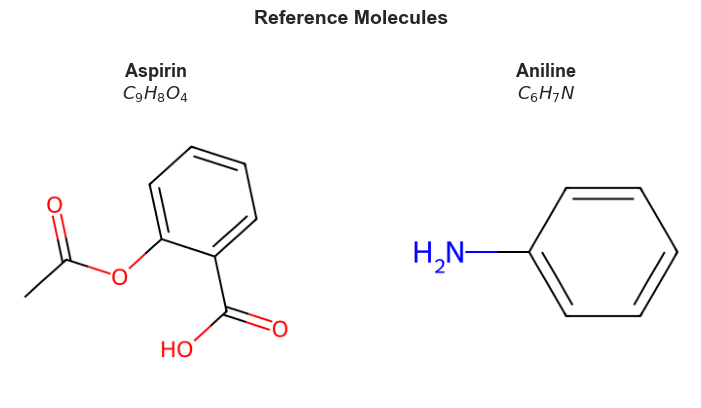

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, smiles, name, formula in zip(
    axes,
    [REF_ASPIRIN, REF_ANILINE],
    ['Aspirin', 'Aniline'],
    ['$C_9H_8O_4$', '$C_6H_7N$'],
):
    img = mol_to_img(smiles, size=(300, 300))
    ax.imshow(img)
    ax.set_title(f'{name}\n{formula}', fontsize=13, fontweight='bold')
    ax.axis('off')

fig.suptitle('Reference Molecules',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### Top-10 Aspirin Analogs by Mahalanobis Angle ($\theta_M$)

The original notebooks rank by **Mahalanobis angle** ($\theta_M$), which captures orientation similarity in the covariance-transformed descriptor space. Compounds with small $\theta_M$ have similar chemical feature distributions to aspirin.

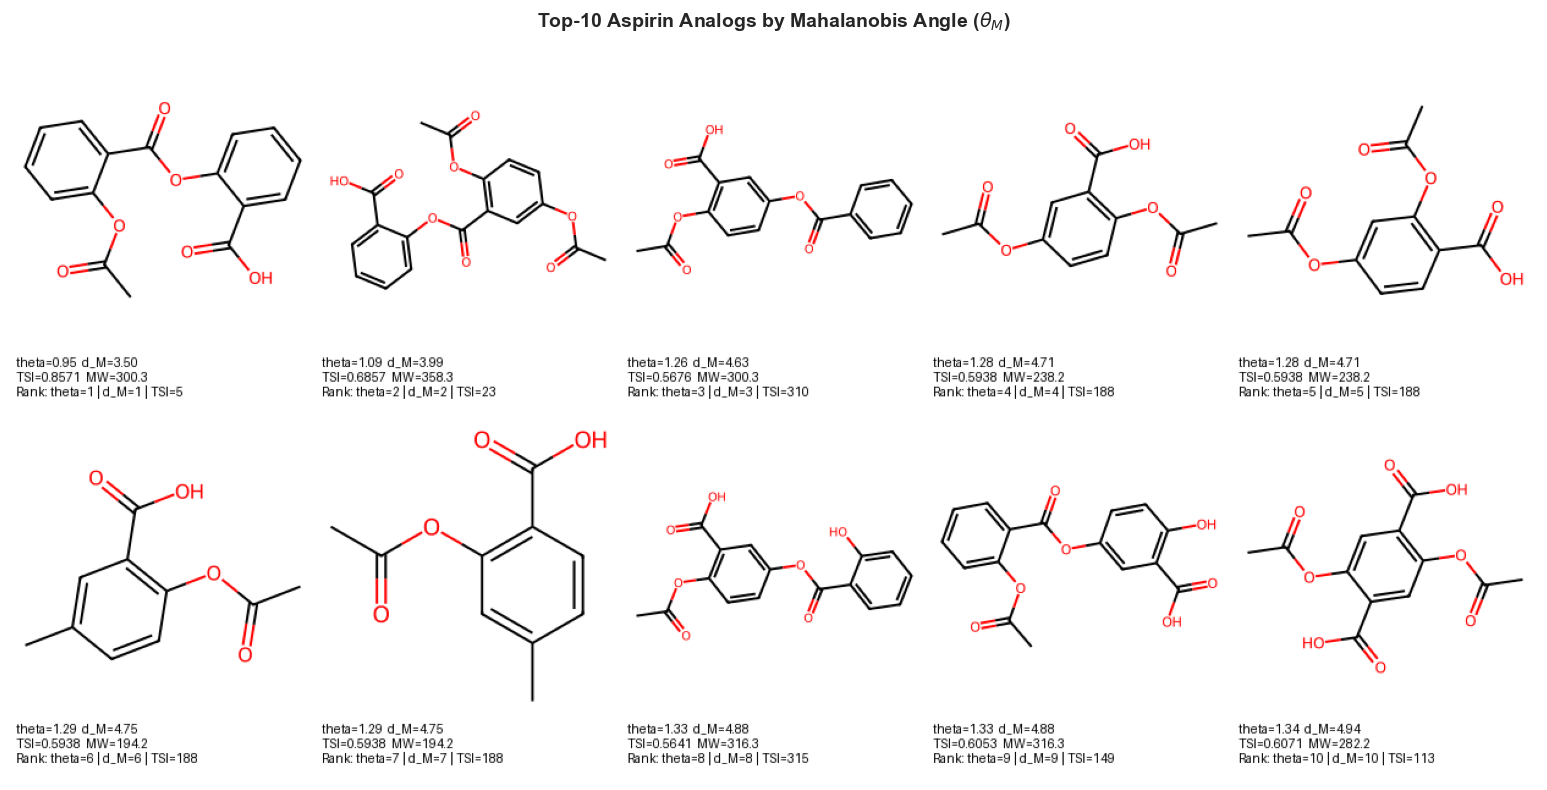

,smiles,theta,mahalanobis_distance,tanimoto_similarity,weight
0,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)O,0.9500,3.4996,0.8571,300.266
1,CC(=O)OC1=CC(=C(C=C1)OC(=O)C)C(=O)OC2=CC=CC=C2...,1.0853,3.9921,0.6857,358.302
2,CC(=O)OC1=C(C=C(C=C1)OC(=O)C2=CC=CC=C2)C(=O)O,1.2588,4.6309,0.5676,300.266
3,CC(=O)OC1=CC(=C(C=C1)OC(=O)C)C(=O)O,1.2792,4.7081,0.5938,238.195
4,CC(=O)OC1=CC(=C(C=C1)C(=O)O)OC(=O)C,1.2792,4.7081,0.5938,238.195
5,CC1=CC(=C(C=C1)OC(=O)C)C(=O)O,1.2898,4.7464,0.5938,194.186
6,CC1=CC(=C(C=C1)C(=O)O)OC(=O)C,1.2898,4.7464,0.5938,194.186
7,CC(=O)OC1=C(C=C(C=C1)OC(=O)C2=CC=CC=C2O)C(=O)O,1.3282,4.8844,0.5641,316.265
8,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC(=C(C=C2)O)C(=O)O,1.3282,4.8844,0.6053,316.265
9,CC(=O)OC1=CC(=C(C=C1C(=O)O)OC(=O)C)C(=O)O,1.3437,4.9443,0.6071,282.204


In [11]:
# Top-10 by Mahalanobis angle (excluding reference at index 0)
candidates = aspirin.iloc[1:].copy()
top10_theta = candidates.nsmallest(10, 'theta').reset_index(drop=True)

# Build labels with metrics and ranks
labels_theta = []
for i, row in top10_theta.iterrows():
    rank_dm = (candidates['mahalanobis_distance'] <= row['mahalanobis_distance']).sum()
    rank_theta = (candidates['theta'] <= row['theta']).sum()
    rank_tsi = (candidates['tanimoto_similarity'] >= row['tanimoto_similarity']).sum()
    labels_theta.append(
        f"theta={row['theta']:.2f}  d_M={row['mahalanobis_distance']:.2f}\n"
        f"TSI={row['tanimoto_similarity']:.4f}  MW={row['weight']:.1f}\n"
        f"Rank: theta={rank_theta} | d_M={rank_dm} | TSI={rank_tsi}"
    )

img = mol_grid(top10_theta['smiles'].tolist(), labels=labels_theta, mols_per_row=5, img_size=(250, 250))

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Top-10 Aspirin Analogs by Mahalanobis Angle ($\\theta_M$)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Data table
display(top10_theta[['smiles', 'theta', 'mahalanobis_distance', 'tanimoto_similarity', 'weight']].round(4))

---
### Top-10 Aspirin Analogs by Tanimoto Similarity (TSI)

The same pool, but ranked by TSI. Both methods identify aspirin analogs, but each highlights different aspects: Tanimoto highlights direct structural overlap, while the Mahalanobis angle highlights similarity in the global distribution of chemical characteristics.

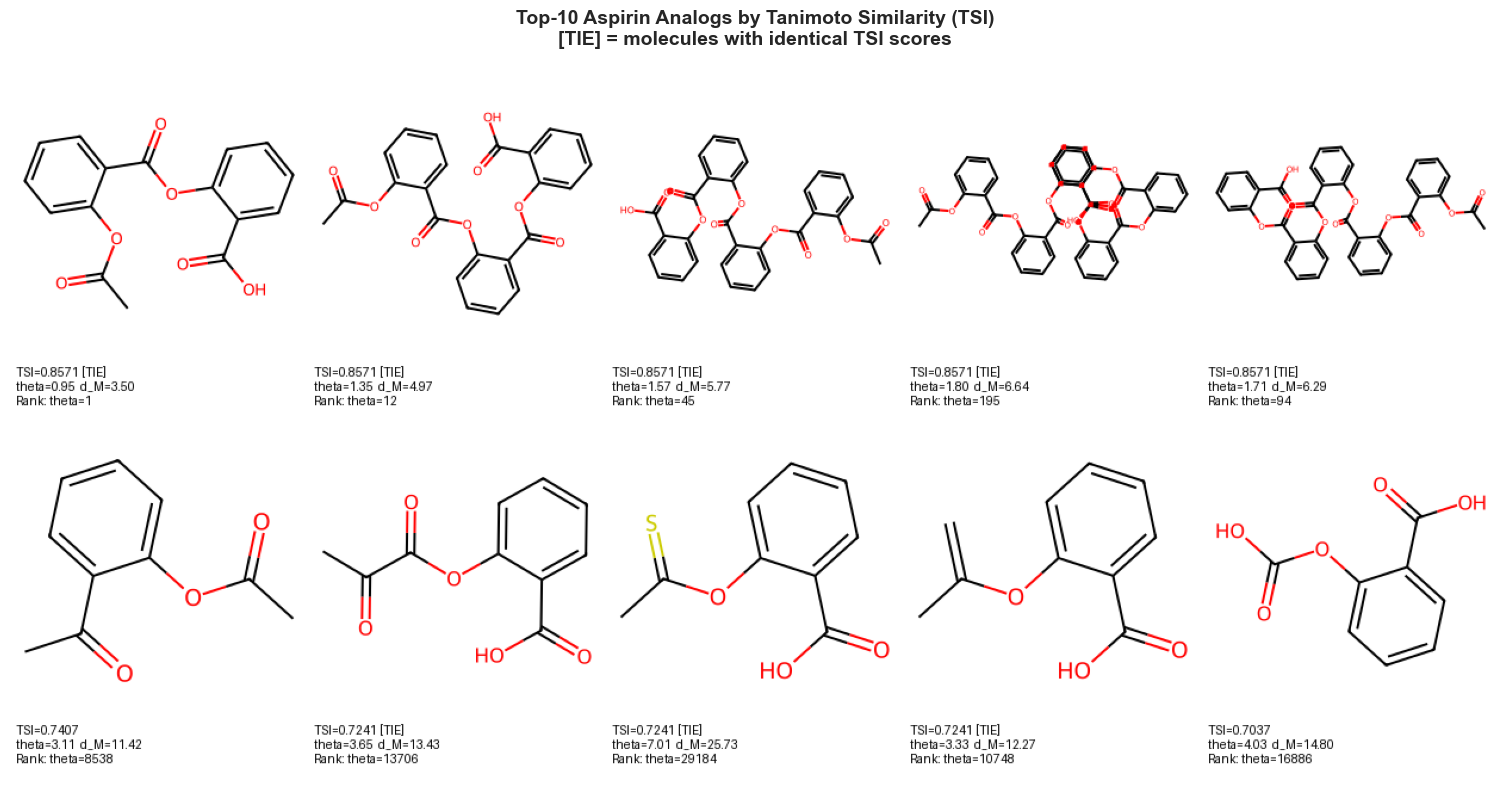

Tanimoto ties in top-10:
  TSI = 0.8571: 5 molecules tied
  TSI = 0.7241: 3 molecules tied


,smiles,tanimoto_similarity,theta,mahalanobis_distance,weight
0,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)O,0.8571,0.9500,3.4996,300.266
1,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)OC3=CC...,0.8571,1.3489,4.9672,420.373
2,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)OC3=CC...,0.8571,1.5685,5.7744,540.480
3,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)OC3=CC...,0.8571,1.8033,6.6372,780.694
4,CC(=O)OC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)OC3=CC...,0.8571,1.7074,6.2850,660.587
5,CC(=O)C1=CC=CC=C1OC(=O)C,0.7407,3.1075,11.4230,178.187
6,CC(=O)C(=O)OC1=CC=CC=C1C(=O)O,0.7241,3.6541,13.4298,208.169
7,CC(=S)OC1=CC=CC=C1C(=O)O,0.7241,7.0120,25.7331,196.227
8,CC(=C)OC1=CC=CC=C1C(=O)O,0.7241,3.3343,12.2722,178.187
9,C1=CC=C(C(=C1)C(=O)O)OC(=O)O,0.7037,4.0278,14.8020,182.131


In [12]:
# Top-10 by Tanimoto similarity
top10_tsi = candidates.nlargest(10, 'tanimoto_similarity').reset_index(drop=True)

# Identify ties
tsi_values = top10_tsi['tanimoto_similarity'].round(4)
tie_groups = tsi_values.value_counts()
ties = tie_groups[tie_groups > 1]

labels_tsi = []
for i, row in top10_tsi.iterrows():
    tsi_val = round(row['tanimoto_similarity'], 4)
    tie_marker = ' [TIE]' if tsi_val in ties.index else ''
    rank_theta = (candidates['theta'] <= row['theta']).sum()
    labels_tsi.append(
        f"TSI={row['tanimoto_similarity']:.4f}{tie_marker}\n"
        f"theta={row['theta']:.2f}  d_M={row['mahalanobis_distance']:.2f}\n"
        f"Rank: theta={rank_theta}"
    )

img = mol_grid(top10_tsi['smiles'].tolist(), labels=labels_tsi, mols_per_row=5, img_size=(250, 250))

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Top-10 Aspirin Analogs by Tanimoto Similarity (TSI)\n'
             '[TIE] = molecules with identical TSI scores',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Tie report
print(f'Tanimoto ties in top-10:')
for val, count in ties.items():
    print(f'  TSI = {val}: {count} molecules tied')

display(top10_tsi[['smiles', 'tanimoto_similarity', 'theta', 'mahalanobis_distance', 'weight']].round(4))

---
### TSI vs Mahalanobis Metrics (ACI, Aspirin Query)

Two-panel scatter plot showing the relationship between TSI and both Mahalanobis metrics. The original notebooks observe that this resembles a rational function with asymptotic behavior.

LOWESS smoother with `frac=0.5`.

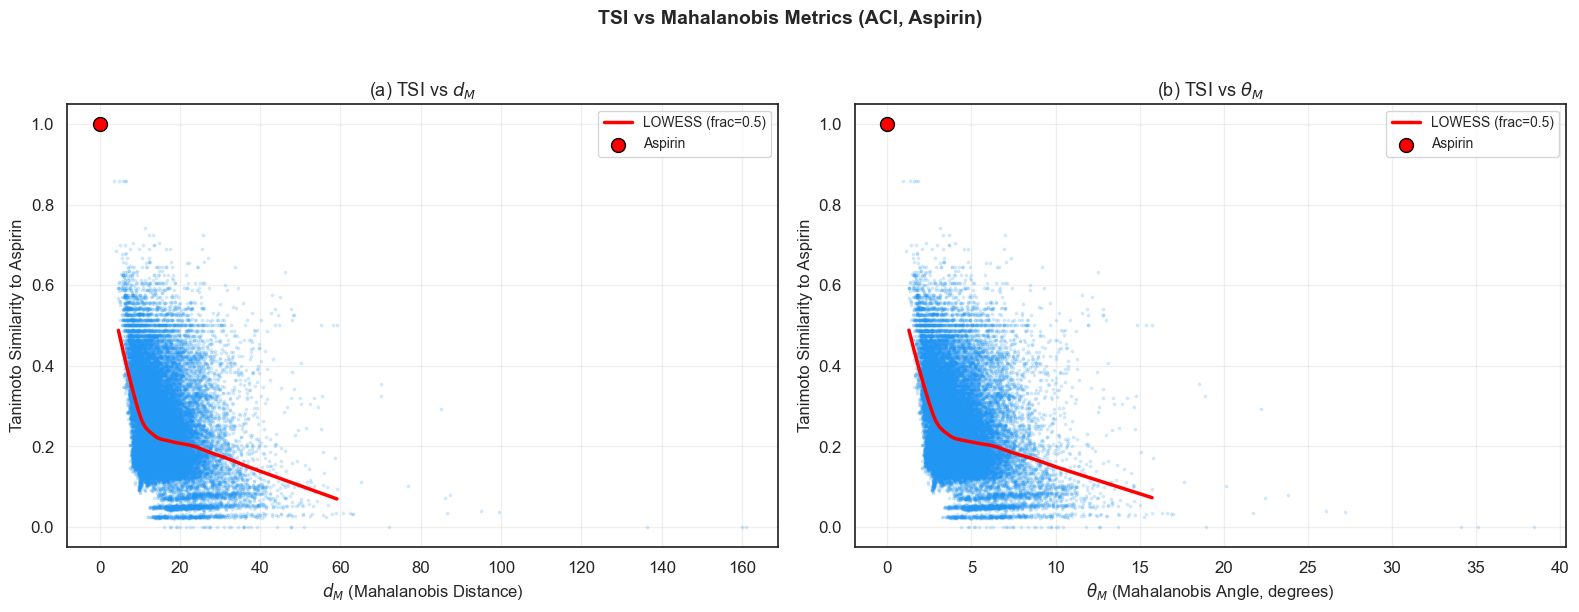

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subsample for LOWESS
sample = aspirin.sample(min(5000, len(aspirin)), random_state=42)

# --- Panel (a): TSI vs d_M ---
ax = axes[0]
ax.scatter(aspirin['mahalanobis_distance'], aspirin['tanimoto_similarity'],
           alpha=0.15, s=3, c='#2196F3', rasterized=True)

s_a = sample.sort_values('mahalanobis_distance')
lowess_a = sm.nonparametric.lowess(
    s_a['tanimoto_similarity'], s_a['mahalanobis_distance'],
    frac=PARAMS['lowess_frac']
)
ax.plot(lowess_a[:, 0], lowess_a[:, 1], color='red', lw=2.5, label='LOWESS (frac=0.5)')
ax.scatter(0, 1, color='red', s=100, zorder=5, edgecolors='black', label='Aspirin')

ax.set_xlabel('$d_M$ (Mahalanobis Distance)', fontsize=12)
ax.set_ylabel('Tanimoto Similarity to Aspirin', fontsize=12)
ax.set_title('(a) TSI vs $d_M$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel (b): TSI vs theta_M ---
ax = axes[1]
ax.scatter(aspirin['theta'], aspirin['tanimoto_similarity'],
           alpha=0.15, s=3, c='#2196F3', rasterized=True)

s_b = sample.sort_values('theta')
lowess_b = sm.nonparametric.lowess(
    s_b['tanimoto_similarity'], s_b['theta'],
    frac=PARAMS['lowess_frac']
)
ax.plot(lowess_b[:, 0], lowess_b[:, 1], color='red', lw=2.5, label='LOWESS (frac=0.5)')
ax.scatter(0, 1, color='red', s=100, zorder=5, edgecolors='black', label='Aspirin')

ax.set_xlabel('$\\theta_M$ (Mahalanobis Angle, degrees)', fontsize=12)
ax.set_ylabel('Tanimoto Similarity to Aspirin', fontsize=12)
ax.set_title('(b) TSI vs $\\theta_M$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('TSI vs Mahalanobis Metrics (ACI, Aspirin)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation**: The relationship between TSI and the Mahalanobis metrics resembles a rational function with asymptotic behavior. TSI drops steeply in the high-similarity zone and then plateaus near zero — suggesting that MSI metrics continue discriminating in regions where TSI has lost resolution. This pattern is consistent across reference molecules.

---
### 3D Similarity Map (Aspirin)

Three-dimensional landscape: $\theta_M$ (x) × $d_M$ (y) × TSI (z, color). Colored by molecular weight, filtered to $MW \leq 500$.

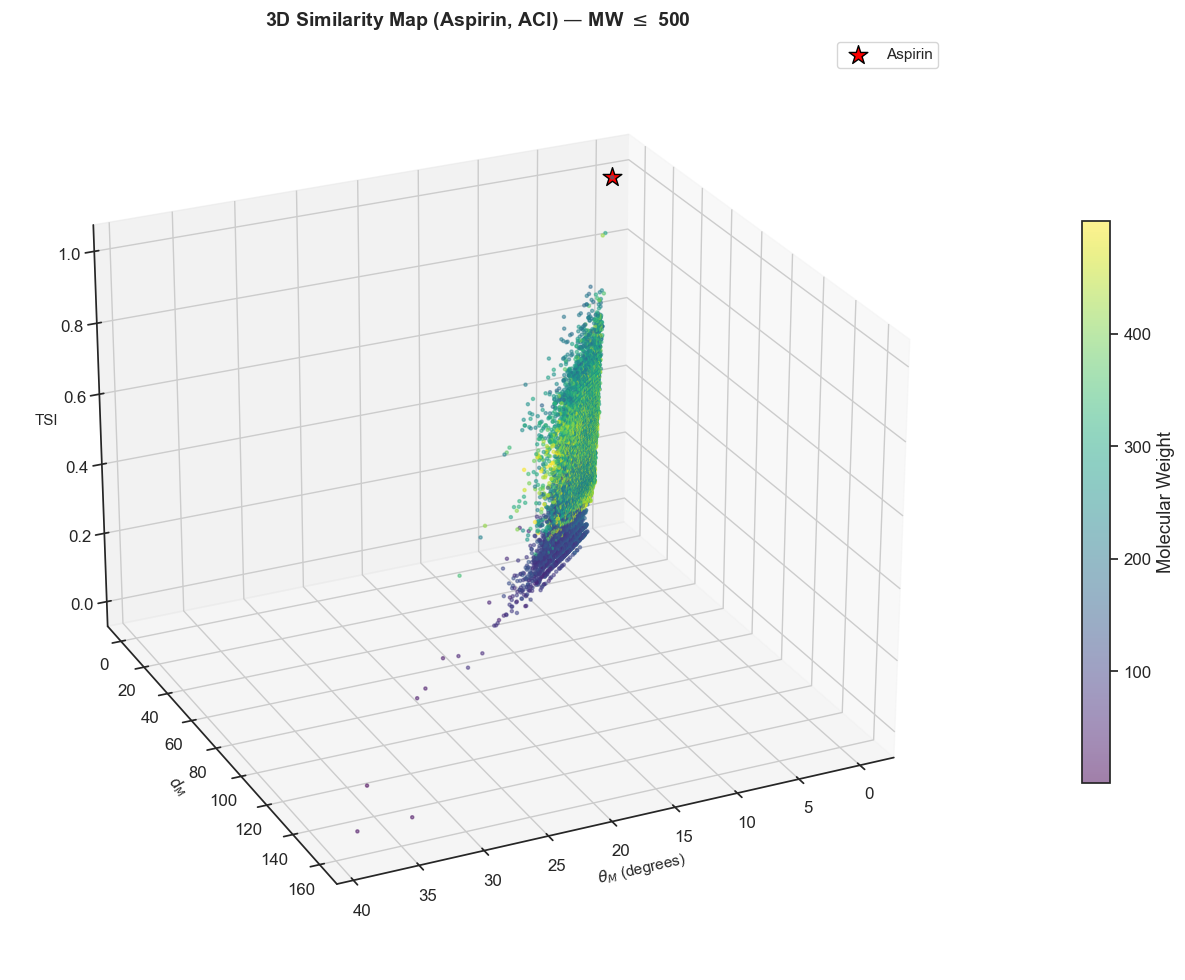

In [14]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

df_plot = aspirin[aspirin['weight'] <= 500].copy()

sc = ax.scatter(
    df_plot['theta'], df_plot['mahalanobis_distance'],
    df_plot['tanimoto_similarity'],
    c=df_plot['weight'], cmap='viridis',
    alpha=0.5, s=5, rasterized=True
)

# Aspirin at origin
ax.scatter(0, 0, 1, color='red', s=200, marker='*',
           edgecolors='black', zorder=5, label='Aspirin')

ax.set_xlabel('$\\theta_M$ (degrees)', fontsize=11)
ax.set_ylabel('$d_M$', fontsize=11)
ax.set_zlabel('TSI', fontsize=11)
ax.set_title('3D Similarity Map (Aspirin, ACI) — MW $\\leq$ 500', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.colorbar(sc, ax=ax, label='Molecular Weight', shrink=0.6, pad=0.1)
ax.view_init(elev=25, azim=65)
plt.tight_layout()
plt.show()

---
### Polar Representation (Aspirin)

Polar plot with:
- **Radial axis** = $d_M$ (distance from aspirin)
- **Angular axis** = $\theta_M$ (Mahalanobis angle, 0° to 180°)
- **Color** = $d_M$ (intensity encodes distance)

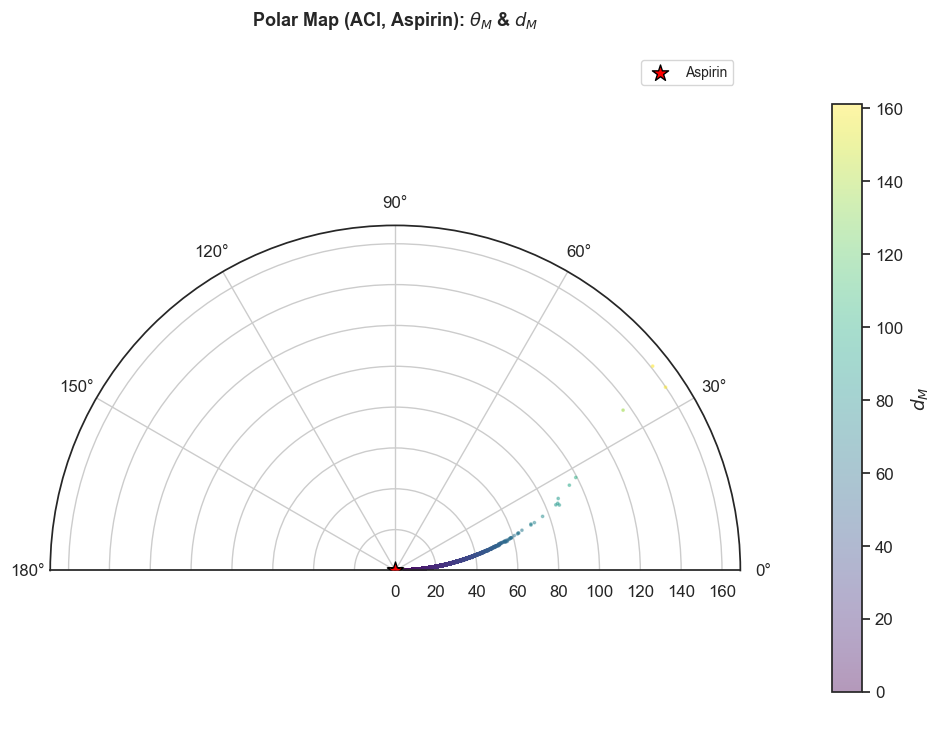

Molecules with theta_M < 10 and d_M < 80: 31,000 (98.7%)
Max theta_M: 38.45 degrees
Max d_M: 160.94


In [15]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

ax.set_thetamin(0)
ax.set_thetamax(180)

sc = ax.scatter(
    aspirin['radians'], aspirin['mahalanobis_distance'],
    c=aspirin['mahalanobis_distance'], cmap='viridis',
    alpha=0.4, s=3, rasterized=True
)

# Reference at origin
ax.scatter(0, 0, color='red', s=150, zorder=5, marker='*',
           edgecolors='black', label='Aspirin')

ax.set_title('Polar Map (ACI, Aspirin): $\\theta_M$ & $d_M$',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10)
plt.colorbar(sc, ax=ax, label='$d_M$', pad=0.1, shrink=0.8)
plt.tight_layout()
plt.show()

# Zone statistics
in_zone = ((aspirin['theta'] < 10) & (aspirin['mahalanobis_distance'] < 80)).sum()
pct = 100 * in_zone / len(aspirin)
print(f'Molecules with theta_M < 10 and d_M < 80: {in_zone:,} ({pct:.1f}%)')
print(f'Max theta_M: {aspirin["theta"].max():.2f} degrees')
print(f'Max d_M: {aspirin["mahalanobis_distance"].max():.2f}')

---
## Case Study II: QM9 Dataset (Aniline Reference)

The QM9 dataset contains ~127k small organic molecules with quantum-chemical properties (HOMO, LUMO, gap). Aniline ($C_6H_7N$, $E_{gap} = 0.2077 E_h$) is the reference molecule.

---

### Top-10 Aniline Analogs by Mahalanobis Angle ($\theta_M$)

Aniline E_gap: 0.2077 E_h


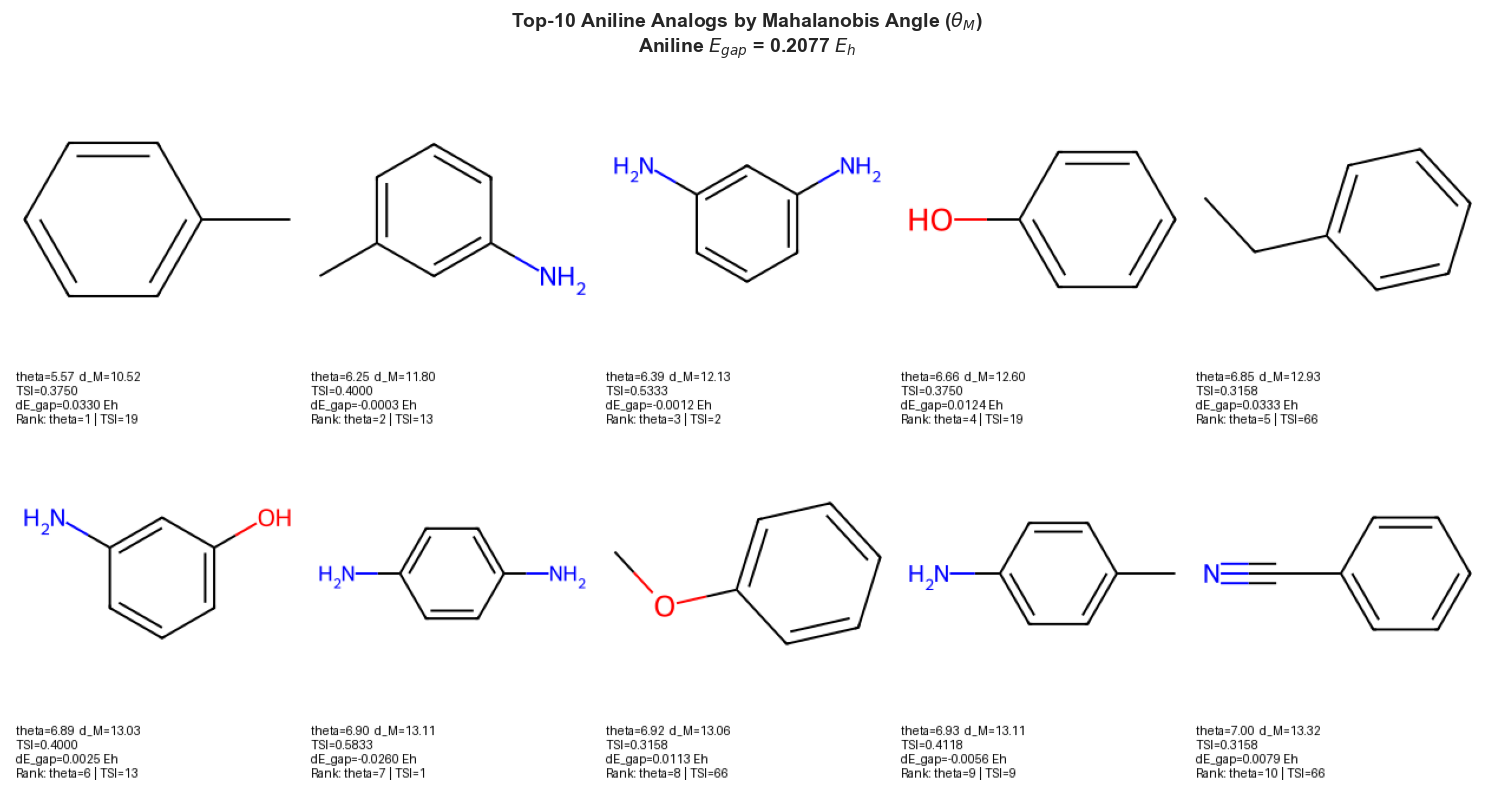

,smiles,theta,mahalanobis_distance,tanimoto_similarity,gap,delta_gap
0,Cc1ccccc1,5.5696,10.5210,0.3750,0.2407,0.0330
1,Cc1cccc(c1)N,6.2460,11.8049,0.4000,0.2074,-0.0003
2,c1cc(cc(c1)N)N,6.3911,12.1258,0.5333,0.2065,-0.0012
3,c1ccc(cc1)O,6.6625,12.5987,0.3750,0.2201,0.0124
4,CCc1ccccc1,6.8534,12.9344,0.3158,0.2410,0.0333
5,c1cc(cc(c1)O)N,6.8883,13.0296,0.4000,0.2102,0.0025
6,c1cc(ccc1N)N,6.8958,13.1052,0.5833,0.1817,-0.0260
7,COc1ccccc1,6.9158,13.0616,0.3158,0.2190,0.0113
8,Cc1ccc(cc1)N,6.9251,13.1061,0.4118,0.2021,-0.0056
9,c1ccc(cc1)C#N,7.0027,13.3234,0.3158,0.2156,0.0079


In [16]:
qm9_candidates = qm9.iloc[1:].copy()
aniline_gap = qm9['gap'].iloc[0]
print(f'Aniline E_gap: {aniline_gap:.4f} E_h')

# Top-10 by Mahalanobis angle
top10_qm9_theta = qm9_candidates.nsmallest(10, 'theta').reset_index(drop=True)
top10_qm9_theta['delta_gap'] = top10_qm9_theta['gap'] - aniline_gap

labels_qm9_theta = []
for i, row in top10_qm9_theta.iterrows():
    rank_theta = (qm9_candidates['theta'] <= row['theta']).sum()
    rank_tsi = (qm9_candidates['tanimoto_similarity'] >= row['tanimoto_similarity']).sum()
    labels_qm9_theta.append(
        f"theta={row['theta']:.2f}  d_M={row['mahalanobis_distance']:.2f}\n"
        f"TSI={row['tanimoto_similarity']:.4f}\n"
        f"dE_gap={row['delta_gap']:.4f} Eh\n"
        f"Rank: theta={rank_theta} | TSI={rank_tsi}"
    )

img = mol_grid(top10_qm9_theta['smiles'].tolist(), labels=labels_qm9_theta, mols_per_row=5, img_size=(250, 250))

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Top-10 Aniline Analogs by Mahalanobis Angle ($\\theta_M$)\n'
             f'Aniline $E_{{gap}}$ = {aniline_gap:.4f} $E_h$',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

display(top10_qm9_theta[['smiles', 'theta', 'mahalanobis_distance', 'tanimoto_similarity', 'gap', 'delta_gap']].round(4))

---
### Top-10 Aniline Analogs by TSI (Tanimoto)

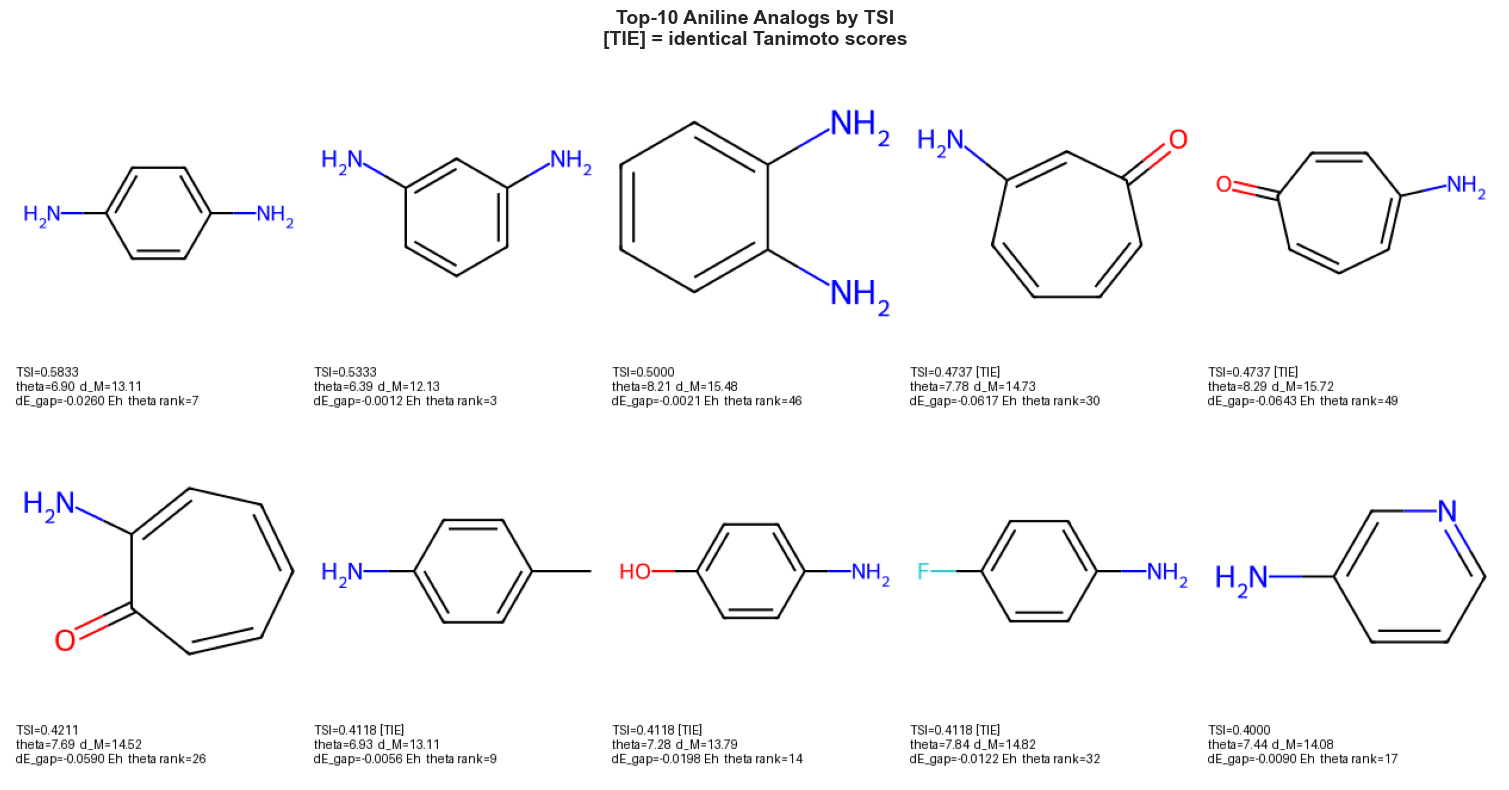

Tanimoto ties in top-10:
  TSI = 0.4118: 3 molecules tied
  TSI = 0.4737: 2 molecules tied


,smiles,tanimoto_similarity,theta,mahalanobis_distance,gap,delta_gap
0,c1cc(ccc1N)N,0.5833,6.8958,13.1052,0.1817,-0.0260
1,c1cc(cc(c1)N)N,0.5333,6.3911,12.1258,0.2065,-0.0012
2,c1ccc(c(c1)N)N,0.5000,8.2123,15.4783,0.2056,-0.0021
3,c1ccc(=O)cc(c1)N,0.4737,7.7763,14.7317,0.1460,-0.0617
4,c1cc(ccc(=O)c1)N,0.4737,8.2854,15.7194,0.1434,-0.0643
5,c1ccc(c(=O)cc1)N,0.4211,7.6869,14.5214,0.1487,-0.0590
6,Cc1ccc(cc1)N,0.4118,6.9251,13.1061,0.2021,-0.0056
7,c1cc(ccc1N)O,0.4118,7.2841,13.7946,0.1879,-0.0198
8,c1cc(ccc1N)F,0.4118,7.8359,14.8239,0.1955,-0.0122
9,c1cc(cnc1)N,0.4000,7.4422,14.0786,0.1987,-0.0090


In [17]:
top10_qm9_tsi = qm9_candidates.nlargest(10, 'tanimoto_similarity').reset_index(drop=True)
top10_qm9_tsi['delta_gap'] = top10_qm9_tsi['gap'] - aniline_gap

# Identify ties
tsi_vals_qm9 = top10_qm9_tsi['tanimoto_similarity'].round(4)
tie_groups_qm9 = tsi_vals_qm9.value_counts()
ties_qm9 = tie_groups_qm9[tie_groups_qm9 > 1]

labels_qm9_tsi = []
for i, row in top10_qm9_tsi.iterrows():
    tsi_val = round(row['tanimoto_similarity'], 4)
    tie_marker = ' [TIE]' if tsi_val in ties_qm9.index else ''
    rank_theta = (qm9_candidates['theta'] <= row['theta']).sum()
    labels_qm9_tsi.append(
        f"TSI={row['tanimoto_similarity']:.4f}{tie_marker}\n"
        f"theta={row['theta']:.2f}  d_M={row['mahalanobis_distance']:.2f}\n"
        f"dE_gap={row['delta_gap']:.4f} Eh  theta rank={rank_theta}"
    )

img = mol_grid(top10_qm9_tsi['smiles'].tolist(), labels=labels_qm9_tsi, mols_per_row=5, img_size=(250, 250))

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Top-10 Aniline Analogs by TSI\n[TIE] = identical Tanimoto scores',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f'Tanimoto ties in top-10:')
for val, count in ties_qm9.items():
    print(f'  TSI = {val}: {count} molecules tied')

display(top10_qm9_tsi[['smiles', 'tanimoto_similarity', 'theta', 'mahalanobis_distance', 'gap', 'delta_gap']].round(4))

---
### Ranking Comparison: MSI ($\theta_M$) vs TSI (Aniline)

We compare the $E_{gap}$ distributions of the top-ranked molecules under each metric to explore whether MSI-ranked analogs tend to have more similar electronic properties.

Top-10 overlap: 3 molecules appear in both rankings


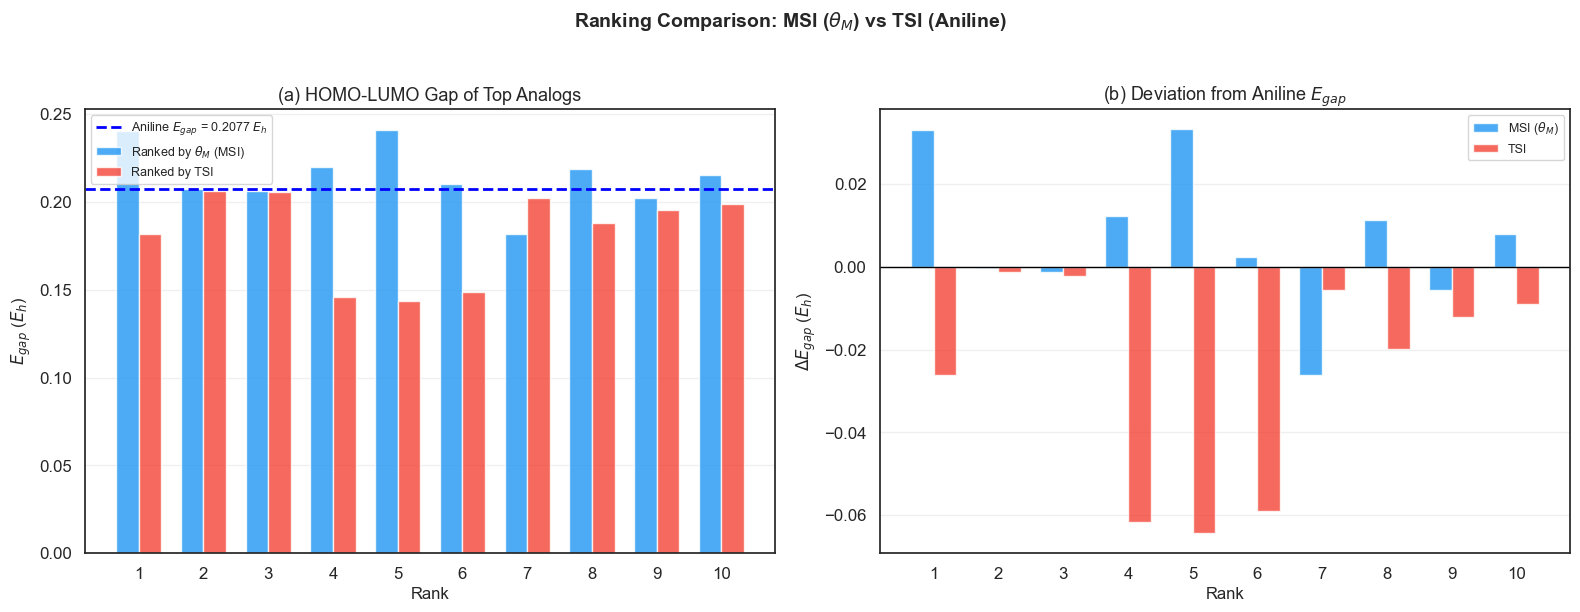


MSI-ranked (theta) E_gap range: [0.1817, 0.2410] E_h
TSI-ranked E_gap range: [0.1434, 0.2065] E_h
MSI mean |delta_gap|: 0.0134 E_h
TSI mean |delta_gap|: 0.0261 E_h


In [18]:
N_TOP = 10

top_by_theta = qm9_candidates.nsmallest(N_TOP, 'theta')
top_by_tsi = qm9_candidates.nlargest(N_TOP, 'tanimoto_similarity')

# Overlap analysis
overlap = set(top_by_theta.index) & set(top_by_tsi.index)
print(f'Top-{N_TOP} overlap: {len(overlap)} molecules appear in both rankings')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel (a): E_gap bar chart ---
ax = axes[0]
x = np.arange(N_TOP)
width = 0.35

bars1 = ax.bar(x - width/2, top_by_theta['gap'].values, width,
               color='#2196F3', alpha=0.8, label='Ranked by $\\theta_M$ (MSI)')
bars2 = ax.bar(x + width/2, top_by_tsi['gap'].values, width,
               color='#F44336', alpha=0.8, label='Ranked by TSI')

ax.axhline(y=aniline_gap, color='blue', linestyle='--', lw=2,
           label=f'Aniline $E_{{gap}}$ = {aniline_gap:.4f} $E_h$')

ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('$E_{gap}$ ($E_h$)', fontsize=12)
ax.set_title('(a) HOMO-LUMO Gap of Top Analogs', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(i+1) for i in x])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Panel (b): Delta E_gap comparison ---
ax = axes[1]

delta_theta = top_by_theta['gap'].values - aniline_gap
delta_tsi = top_by_tsi['gap'].values - aniline_gap

ax.bar(x - width/2, delta_theta, width, color='#2196F3', alpha=0.8, label='MSI ($\\theta_M$)')
ax.bar(x + width/2, delta_tsi, width, color='#F44336', alpha=0.8, label='TSI')
ax.axhline(y=0, color='black', linestyle='-', lw=1)

ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('$\\Delta E_{gap}$ ($E_h$)', fontsize=12)
ax.set_title('(b) Deviation from Aniline $E_{gap}$', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(i+1) for i in x])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Ranking Comparison: MSI ($\\theta_M$) vs TSI (Aniline)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistics
print(f'\nMSI-ranked (theta) E_gap range: [{top_by_theta["gap"].min():.4f}, {top_by_theta["gap"].max():.4f}] E_h')
print(f'TSI-ranked E_gap range: [{top_by_tsi["gap"].min():.4f}, {top_by_tsi["gap"].max():.4f}] E_h')
print(f'MSI mean |delta_gap|: {np.abs(delta_theta).mean():.4f} E_h')
print(f'TSI mean |delta_gap|: {np.abs(delta_tsi).mean():.4f} E_h')

**Observation**: We can compare whether MSI-ranked analogs ($\theta_M$) tend to have $E_{gap}$ values closer to aniline than TSI-ranked analogs. This would suggest that Mahalanobis proximity in descriptor space correlates with genuine electronic similarity.

---
### TSI vs Mahalanobis Metrics (QM9, Aniline Query)

Same layout as the ACI scatter plots but for the much larger QM9 dataset.

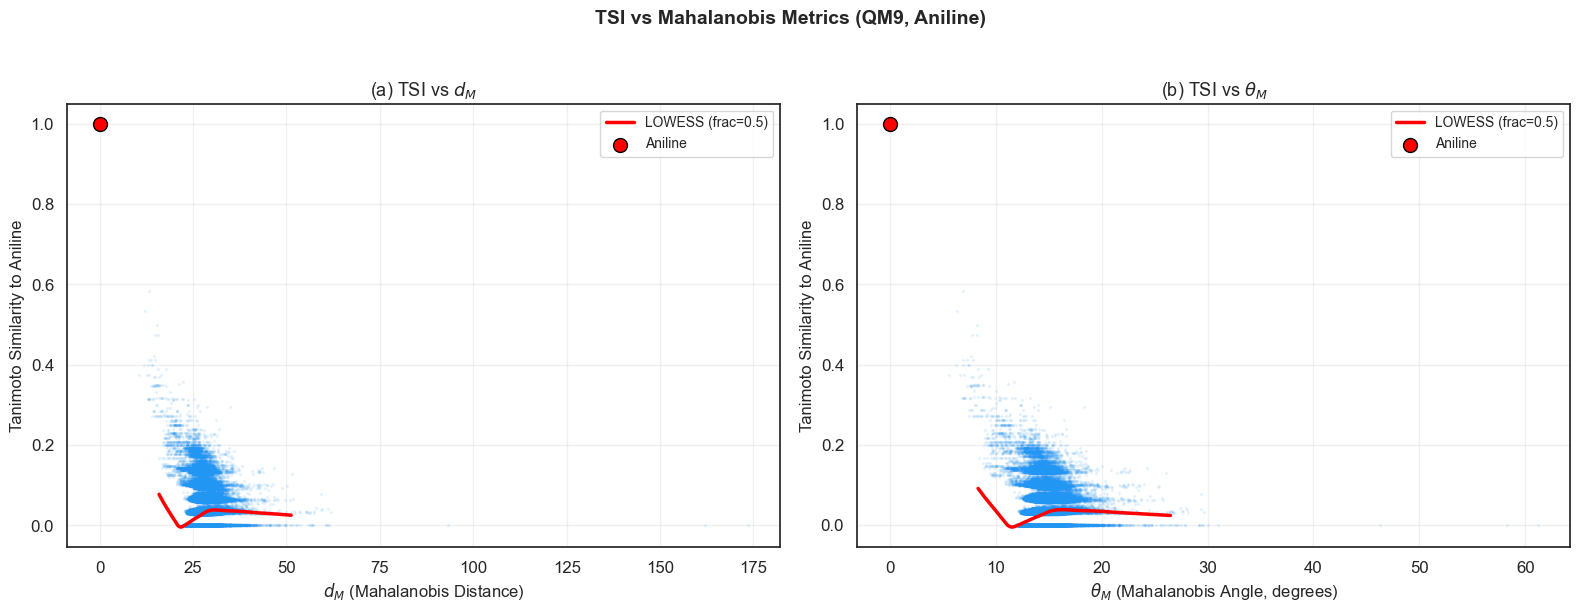

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_qm9 = qm9.sample(min(5000, len(qm9)), random_state=42)

# --- Panel (a): TSI vs d_M ---
ax = axes[0]
ax.scatter(qm9['mahalanobis_distance'], qm9['tanimoto_similarity'],
           alpha=0.08, s=2, c='#2196F3', rasterized=True)

s_a = sample_qm9.sort_values('mahalanobis_distance')
lowess_a = sm.nonparametric.lowess(
    s_a['tanimoto_similarity'], s_a['mahalanobis_distance'],
    frac=PARAMS['lowess_frac']
)
ax.plot(lowess_a[:, 0], lowess_a[:, 1], color='red', lw=2.5, label='LOWESS (frac=0.5)')
ax.scatter(0, qm9['tanimoto_similarity'].iloc[0], color='red', s=100,
           zorder=5, edgecolors='black', label='Aniline')

ax.set_xlabel('$d_M$ (Mahalanobis Distance)', fontsize=12)
ax.set_ylabel('Tanimoto Similarity to Aniline', fontsize=12)
ax.set_title('(a) TSI vs $d_M$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel (b): TSI vs theta_M ---
ax = axes[1]
ax.scatter(qm9['theta'], qm9['tanimoto_similarity'],
           alpha=0.08, s=2, c='#2196F3', rasterized=True)

s_b = sample_qm9.sort_values('theta')
lowess_b = sm.nonparametric.lowess(
    s_b['tanimoto_similarity'], s_b['theta'],
    frac=PARAMS['lowess_frac']
)
ax.plot(lowess_b[:, 0], lowess_b[:, 1], color='red', lw=2.5, label='LOWESS (frac=0.5)')
ax.scatter(0, qm9['tanimoto_similarity'].iloc[0], color='red', s=100,
           zorder=5, edgecolors='black', label='Aniline')

ax.set_xlabel('$\\theta_M$ (Mahalanobis Angle, degrees)', fontsize=12)
ax.set_ylabel('Tanimoto Similarity to Aniline', fontsize=12)
ax.set_title('(b) TSI vs $\\theta_M$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('TSI vs Mahalanobis Metrics (QM9, Aniline)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### Polar Representation (QM9, Aniline)

Broader angular spread than ACI is expected due to QM9's chemical diversity (small organic molecules of many types vs. PubChem substructure-filtered compounds).

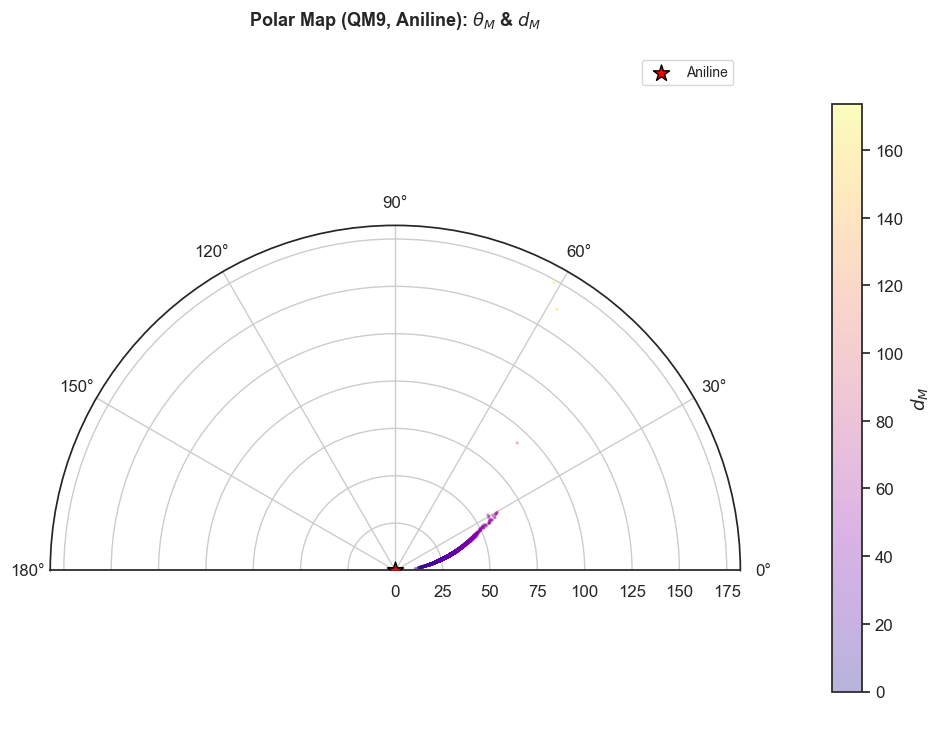

Inner zone (theta < 10, d_M < 25): 185 molecules (0.1%)
Middle zone (10 <= theta < 25, 25 <= d_M < 75): 108,742 molecules (85.3%)
Max theta_M: 61.19 degrees
Max d_M: 173.51


In [20]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

ax.set_thetamin(0)
ax.set_thetamax(180)

sc = ax.scatter(
    qm9['radians'], qm9['mahalanobis_distance'],
    c=qm9['mahalanobis_distance'], cmap='plasma',
    alpha=0.3, s=2, rasterized=True
)

ax.scatter(0, 0, color='red', s=150, zorder=5, marker='*',
           edgecolors='black', label='Aniline')

ax.set_title('Polar Map (QM9, Aniline): $\\theta_M$ & $d_M$',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10)
plt.colorbar(sc, ax=ax, label='$d_M$', pad=0.1, shrink=0.8)
plt.tight_layout()
plt.show()

# Zone statistics
in_inner = ((qm9['theta'] < 10) & (qm9['mahalanobis_distance'] < 25)).sum()
pct_inner = 100 * in_inner / len(qm9)

in_mid = ((qm9['theta'] >= 10) & (qm9['theta'] < 25) &
          (qm9['mahalanobis_distance'] >= 25) & (qm9['mahalanobis_distance'] < 75)).sum()
pct_mid = 100 * in_mid / len(qm9)

print(f'Inner zone (theta < 10, d_M < 25): {in_inner:,} molecules ({pct_inner:.1f}%)')
print(f'Middle zone (10 <= theta < 25, 25 <= d_M < 75): {in_mid:,} molecules ({pct_mid:.1f}%)')
print(f'Max theta_M: {qm9["theta"].max():.2f} degrees')
print(f'Max d_M: {qm9["mahalanobis_distance"].max():.2f}')

---
### 3D: Mahalanobis Geometry vs HOMO-LUMO Gap

Unique to the QM9 dataset: we can explore whether molecules close to aniline in Mahalanobis space also have similar electronic properties ($E_{gap}$). This plot maps $\theta_M$ × $d_M$ × $E_{gap}$.

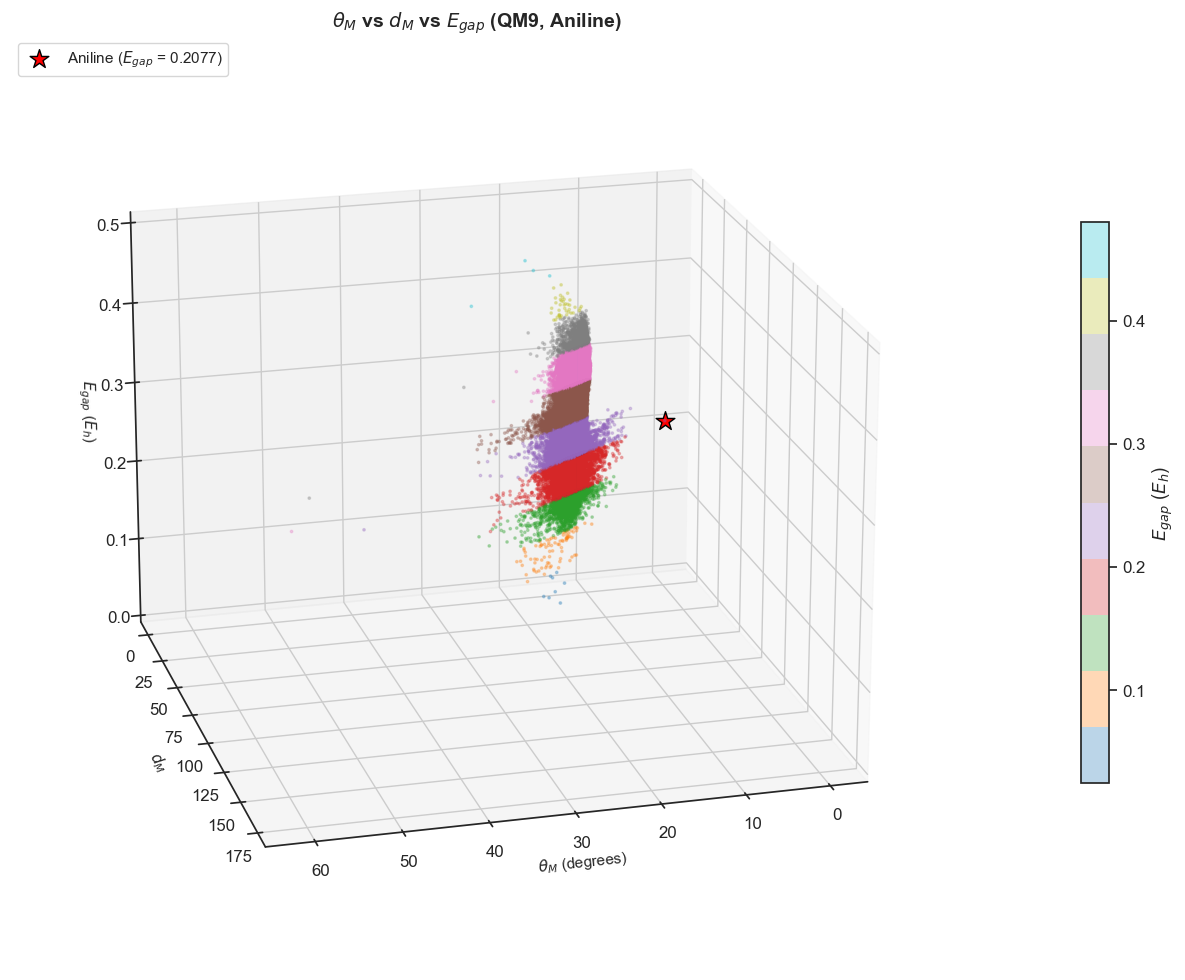

In [21]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    qm9['theta'], qm9['mahalanobis_distance'], qm9['gap'],
    c=qm9['gap'], cmap='tab10',
    alpha=0.3, s=3, rasterized=True
)

# Aniline
ax.scatter(
    0, 0, aniline_gap,
    color='red', s=200, marker='*',
    edgecolors='black', zorder=5, label=f'Aniline ($E_{{gap}}$ = {aniline_gap:.4f})',
)

ax.set_xlabel('$\\theta_M$ (degrees)', fontsize=11)
ax.set_ylabel('$d_M$', fontsize=11)
ax.set_zlabel('$E_{gap}$ ($E_h$)', fontsize=11)
ax.set_title('$\\theta_M$ vs $d_M$ vs $E_{gap}$ (QM9, Aniline)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
plt.colorbar(sc, ax=ax, label='$E_{gap}$ ($E_h$)', shrink=0.6, pad=0.1)
ax.view_init(elev=20, azim=75)
plt.tight_layout()
plt.show()

---
## Cross-Reference Comparison: Aspirin vs Ibuprofen vs Curcumin

The three ACI reference molecules produce the same qualitative pattern (rational-function decay of TSI vs $d_M$), but with reference-dependent quantitative differences. This consistency suggests the MSI framework behaves predictably across different molecular queries.

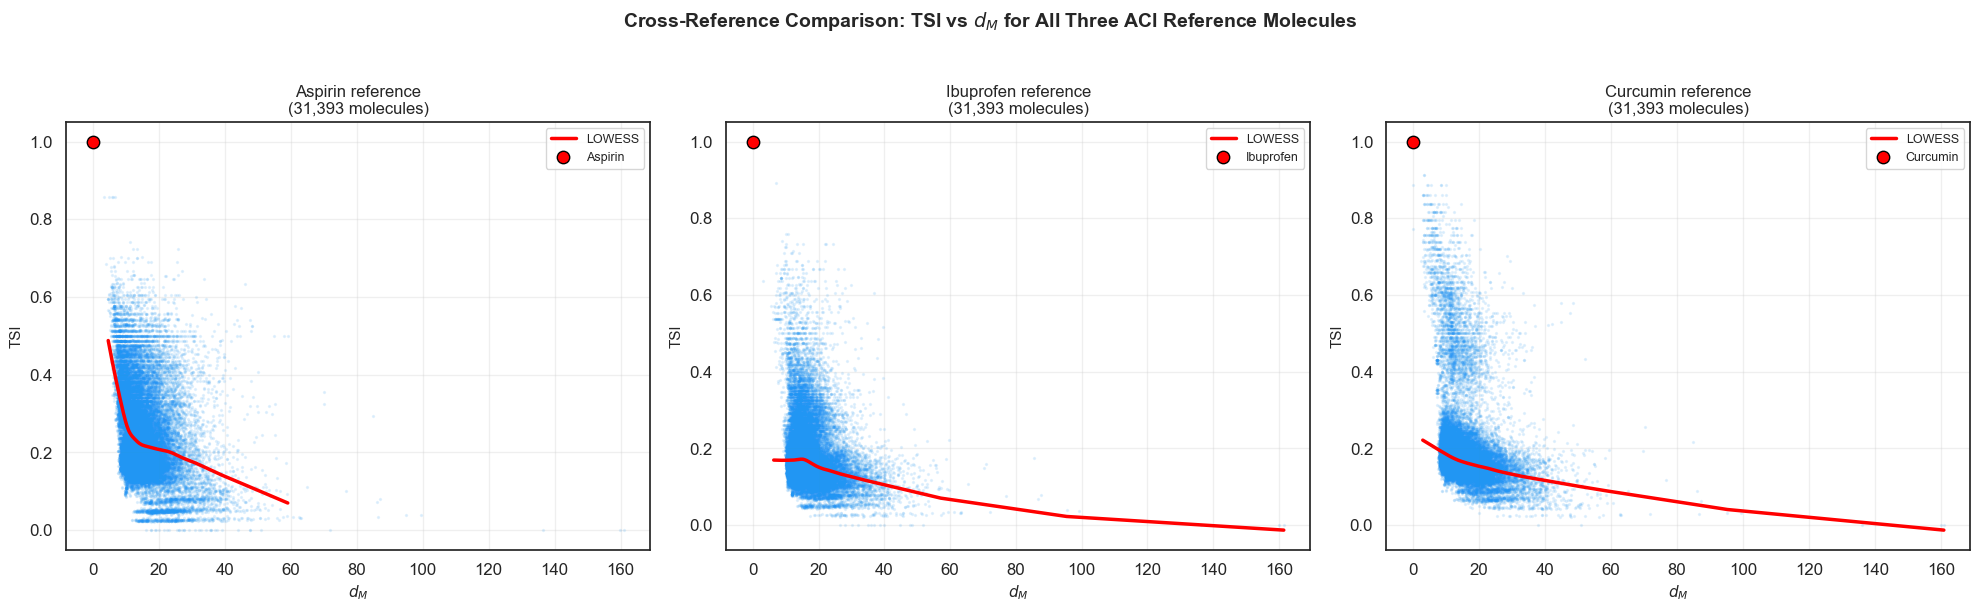


Dataset summary:
  Aspirin: d_M range [0, 160.94], theta range [0, 38.45], top analog d_M=3.50
  Ibuprofen: d_M range [0, 161.47], theta range [0, 38.59], top analog d_M=3.24
  Curcumin: d_M range [0, 160.95], theta range [0, 38.45], top analog d_M=0.00


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, df, ref_name) in zip(axes, [
    ('aspirin', aspirin, 'Aspirin'),
    ('ibuprofen', ibuprofen, 'Ibuprofen'),
    ('curcumin', curcumin, 'Curcumin'),
]):
    sample_df = df.sample(min(5000, len(df)), random_state=42)
    
    ax.scatter(df['mahalanobis_distance'], df['tanimoto_similarity'],
              alpha=0.1, s=2, c='#2196F3', rasterized=True)
    
    s = sample_df.sort_values('mahalanobis_distance')
    lowess_fit = sm.nonparametric.lowess(
        s['tanimoto_similarity'], s['mahalanobis_distance'],
        frac=PARAMS['lowess_frac']
    )
    ax.plot(lowess_fit[:, 0], lowess_fit[:, 1], color='red', lw=2.5, label='LOWESS')
    ax.scatter(0, 1, color='red', s=80, zorder=5, edgecolors='black', label=ref_name)
    
    ax.set_xlabel('$d_M$', fontsize=11)
    ax.set_ylabel('TSI', fontsize=11)
    ax.set_title(f'{ref_name} reference\n({len(df):,} molecules)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Cross-Reference Comparison: TSI vs $d_M$ for All Three ACI Reference Molecules',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print('\nDataset summary:')
for name, df in [('Aspirin', aspirin), ('Ibuprofen', ibuprofen), ('Curcumin', curcumin)]:
    cands = df.iloc[1:]
    top1 = cands.nsmallest(1, 'mahalanobis_distance').iloc[0]
    print(f'  {name}: d_M range [0, {df["mahalanobis_distance"].max():.2f}], '
          f'theta range [0, {df["theta"].max():.2f}], '
          f'top analog d_M={top1["mahalanobis_distance"]:.2f}')

---
## Results Summary

Quantitative overview of the freshly-generated results across all datasets.

In [23]:
print('=' * 80)
print('  RESULTS SUMMARY')
print('  (All results generated fresh with msi.py pipeline)')
print('=' * 80)

# --- ACI Dataset ---
print('\n--- Case Study I: ACI (Aspirin) ---')
print(f'  Dataset size: {len(aspirin):,} molecules')
print(f'  d_M range: [0, {aspirin["mahalanobis_distance"].max():.2f}]')
print(f'  theta_M range: [0, {aspirin["theta"].max():.2f}] degrees')
print(f'  TSI range: [{aspirin["tanimoto_similarity"].min():.4f}, {aspirin["tanimoto_similarity"].max():.4f}]')

# Top analog by theta
top1_asp = aspirin.iloc[1:].nsmallest(1, 'theta').iloc[0]
print(f'  Top analog (theta): theta={top1_asp["theta"]:.2f}, '
      f'd_M={top1_asp["mahalanobis_distance"]:.2f}, TSI={top1_asp["tanimoto_similarity"]:.4f}')

# TSI ties in top-10
top10_tsi_vals = aspirin.iloc[1:].nlargest(10, 'tanimoto_similarity')['tanimoto_similarity'].round(4)
n_unique_tsi = top10_tsi_vals.nunique()
print(f'  Top-10 by TSI: {n_unique_tsi} unique values (ties present: {n_unique_tsi < 10})')

# Concentration zone
zone_pct = 100 * ((aspirin['theta'] < 10) & (aspirin['mahalanobis_distance'] < 80)).sum() / len(aspirin)
print(f'  Molecules in theta<10, d_M<80: {zone_pct:.1f}%')

# Descriptive statistics (as in original notebooks)
print(f'\n  Descriptive stats:')
print(f'    theta: mean={aspirin["theta"].mean():.2f}, std={aspirin["theta"].std():.2f}, '
      f'min={aspirin["theta"].min():.2f}, max={aspirin["theta"].max():.2f}')
print(f'    d_M:   mean={aspirin["mahalanobis_distance"].mean():.2f}, '
      f'std={aspirin["mahalanobis_distance"].std():.2f}, '
      f'min={aspirin["mahalanobis_distance"].min():.2f}, '
      f'max={aspirin["mahalanobis_distance"].max():.2f}')

# --- ACI cross-references ---
print('\n--- ACI Cross-references ---')
for name, df in [('Ibuprofen', ibuprofen), ('Curcumin', curcumin)]:
    print(f'  {name}: {len(df):,} molecules, '
          f'd_M range [0, {df["mahalanobis_distance"].max():.2f}], '
          f'theta range [0, {df["theta"].max():.2f}]')
    print(f'    theta: mean={df["theta"].mean():.2f}, std={df["theta"].std():.2f}')
    print(f'    d_M:   mean={df["mahalanobis_distance"].mean():.2f}, std={df["mahalanobis_distance"].std():.2f}')

# --- QM9 Dataset ---
print('\n--- Case Study II: QM9 (Aniline) ---')
print(f'  Dataset size: {len(qm9):,} molecules')
print(f'  Aniline E_gap: {aniline_gap:.4f} E_h')
print(f'  d_M range: [0, {qm9["mahalanobis_distance"].max():.2f}]')
print(f'  theta_M range: [0, {qm9["theta"].max():.2f}] degrees')

# Top-10 overlap
top10_theta_idx = set(qm9.iloc[1:].nsmallest(10, 'theta').index)
top10_tsi_idx = set(qm9.iloc[1:].nlargest(10, 'tanimoto_similarity').index)
overlap_count = len(top10_theta_idx & top10_tsi_idx)
print(f'  Top-10 overlap (theta vs TSI): {overlap_count} molecules')

# E_gap proximity comparison
top10_theta_gaps = qm9.iloc[1:].nsmallest(10, 'theta')['gap']
top10_tsi_gaps = qm9.iloc[1:].nlargest(10, 'tanimoto_similarity')['gap']
msi_gap_dev = np.abs(top10_theta_gaps - aniline_gap).mean()
tsi_gap_dev = np.abs(top10_tsi_gaps - aniline_gap).mean()
print(f'  MSI top-10 mean |delta E_gap|: {msi_gap_dev:.4f} E_h')
print(f'  TSI top-10 mean |delta E_gap|: {tsi_gap_dev:.4f} E_h')
print(f'  MSI selects electronically closer analogs: {msi_gap_dev < tsi_gap_dev}')

# Inner zone E_gap coherence
inner = ((qm9['theta'] < 10) & (qm9['mahalanobis_distance'] < 25))
inner_gap_std = qm9.loc[inner, 'gap'].std()
outer_gap_std = qm9.loc[~inner, 'gap'].std()
print(f'  Inner zone E_gap std: {inner_gap_std:.4f} E_h')
print(f'  Outer zone E_gap std: {outer_gap_std:.4f} E_h')
print(f'  Inner zone has lower E_gap variance: {inner_gap_std < outer_gap_std}')

print('\n' + '=' * 80)
print(f'\nOutput files saved to: {os.path.abspath(OUTPUT_DIR)}')

  RESULTS SUMMARY
  (All results generated fresh with msi.py pipeline)

--- Case Study I: ACI (Aspirin) ---
  Dataset size: 31,393 molecules
  d_M range: [0, 160.94]
  theta_M range: [0, 38.45] degrees
  TSI range: [0.0000, 1.0000]
  Top analog (theta): theta=0.95, d_M=3.50, TSI=0.8571
  Top-10 by TSI: 4 unique values (ties present: True)
  Molecules in theta<10, d_M<80: 98.7%

  Descriptive stats:
    theta: mean=4.27, std=1.79, min=0.00, max=38.45
    d_M:   mean=15.73, std=6.69, min=0.00, max=160.94

--- ACI Cross-references ---
  Ibuprofen: 31,393 molecules, d_M range [0, 161.47], theta range [0, 38.59]
    theta: mean=4.71, std=1.67
    d_M:   mean=17.35, std=6.24
  Curcumin: 31,393 molecules, d_M range [0, 160.95], theta range [0, 38.45]
    theta: mean=4.33, std=1.78
    d_M:   mean=15.95, std=6.64

--- Case Study II: QM9 (Aniline) ---
  Dataset size: 127,537 molecules
  Aniline E_gap: 0.2077 E_h
  d_M range: [0, 173.51]
  theta_M range: [0, 61.19] degrees
  Top-10 overlap (thet

---
## Extended Analysis — Strengthening the Results

The following analyses go beyond the core visualizations to stress-test the MSI framework with statistical rigor. They address key questions:

1. **Statistical significance**: Is the MSI advantage over TSI statistically significant? (bootstrap test)
2. **Ranking stability**: How sensitive are rankings to the regularization parameter $\lambda$?
3. **Metric correlation structure**: How do $\theta_M$, $d_M$, TSI, and embedding similarity relate to each other?
4. **Distribution analysis**: What do the $\theta_M$ and $d_M$ distributions actually look like?
5. **QM9 property prediction**: Does proximity in Mahalanobis space predict quantum properties beyond $E_{gap}$?
6. **Expanded ranking comparison**: Top-50 and top-100 overlap to check scale-sensitivity
7. **Cosine baseline**: Does plain cosine distance on mol2vec embeddings perform comparably to Mahalanobis?

---
### Extended 1: Bootstrap Test — MSI vs TSI E_gap Proximity

With only N=10 molecules, a simple comparison of mean $|\Delta E_{gap}|$ lacks statistical power. We use a **bootstrap resampling** approach:

- For each of 10,000 iterations, draw a random set of 10 molecules from the QM9 candidates.
- Compute the mean $|\Delta E_{gap}|$ for each random sample.
- Compare the MSI top-10 and TSI top-10 values against the bootstrap distribution.

This tells us: **are the MSI/TSI top-10 sets genuinely better than random, and is MSI better than TSI?**

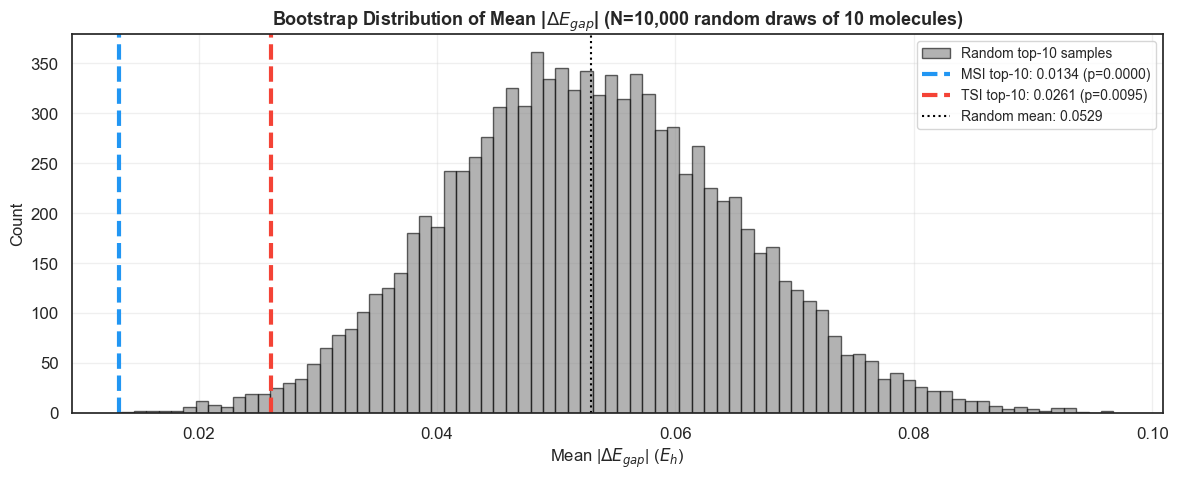

MSI top-10 mean |delta E_gap|: 0.0134 E_h  (p-value: 0.0000)
TSI top-10 mean |delta E_gap|: 0.0261 E_h  (p-value: 0.0095)
Random baseline mean |delta E_gap|: 0.0529 +/- 0.0120 E_h

Interpretation:
  MSI selects molecules with E_gap closer to aniline than 100.0% of random samples
  TSI selects molecules with E_gap closer to aniline than 99.1% of random samples


In [24]:
# Bootstrap test: MSI vs TSI vs random baseline
np.random.seed(42)
N_BOOT = 10_000
N_TOP = 10

qm9_cands = qm9.iloc[1:].copy()
aniline_gap = qm9['gap'].iloc[0]

# Observed values
top_msi = qm9_cands.nsmallest(N_TOP, 'theta')
top_tsi = qm9_cands.nlargest(N_TOP, 'tanimoto_similarity')
obs_msi = np.abs(top_msi['gap'] - aniline_gap).mean()
obs_tsi = np.abs(top_tsi['gap'] - aniline_gap).mean()

# Bootstrap distribution
boot_gaps = np.zeros(N_BOOT)
for b in range(N_BOOT):
    sample_idx = np.random.choice(len(qm9_cands), size=N_TOP, replace=False)
    boot_gaps[b] = np.abs(qm9_cands['gap'].iloc[sample_idx].values - aniline_gap).mean()

# P-values (fraction of random draws <= observed)
p_msi = (boot_gaps <= obs_msi).mean()
p_tsi = (boot_gaps <= obs_tsi).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(boot_gaps, bins=80, alpha=0.6, color='gray', edgecolor='black', label='Random top-10 samples')
ax.axvline(obs_msi, color='#2196F3', lw=3, linestyle='--', label=f'MSI top-10: {obs_msi:.4f} (p={p_msi:.4f})')
ax.axvline(obs_tsi, color='#F44336', lw=3, linestyle='--', label=f'TSI top-10: {obs_tsi:.4f} (p={p_tsi:.4f})')
ax.axvline(boot_gaps.mean(), color='black', lw=1.5, linestyle=':', label=f'Random mean: {boot_gaps.mean():.4f}')

ax.set_xlabel('Mean |$\\Delta E_{gap}$| ($E_h$)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Bootstrap Distribution of Mean |$\\Delta E_{{gap}}$| (N={N_BOOT:,} random draws of {N_TOP} molecules)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'MSI top-{N_TOP} mean |delta E_gap|: {obs_msi:.4f} E_h  (p-value: {p_msi:.4f})')
print(f'TSI top-{N_TOP} mean |delta E_gap|: {obs_tsi:.4f} E_h  (p-value: {p_tsi:.4f})')
print(f'Random baseline mean |delta E_gap|: {boot_gaps.mean():.4f} +/- {boot_gaps.std():.4f} E_h')
print(f'\nInterpretation:')
print(f'  MSI selects molecules with E_gap closer to aniline than {100*(1-p_msi):.1f}% of random samples')
print(f'  TSI selects molecules with E_gap closer to aniline than {100*(1-p_tsi):.1f}% of random samples')

---
### Extended 2: Expanded Top-N Overlap and E_gap Comparison

Does the MSI advantage persist at larger N? We compare MSI vs TSI rankings at N = 10, 25, 50, 100, 250, 500.

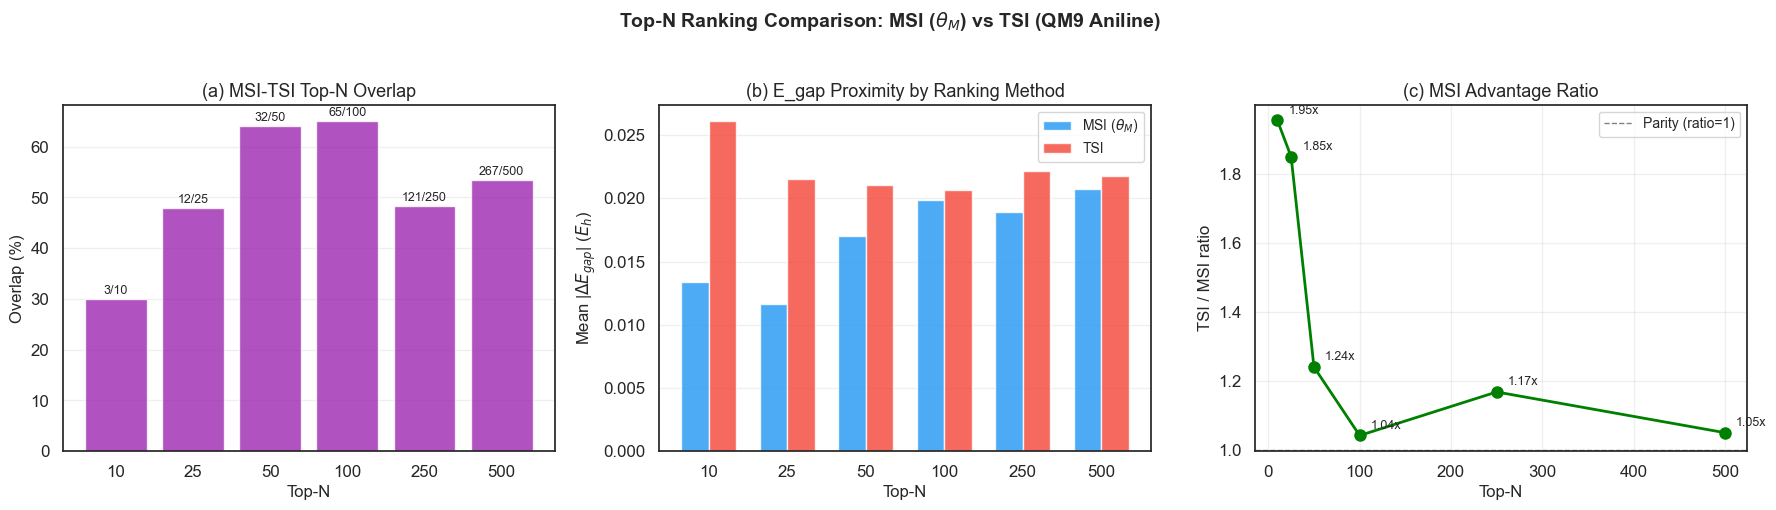

,N,overlap,overlap_pct,msi_gap_dev,tsi_gap_dev,ratio
0,10,3,30.0,0.0134,0.0261,1.9543
1,25,12,48.0,0.0116,0.0215,1.8493
2,50,32,64.0,0.0170,0.0211,1.2401
3,100,65,65.0,0.0199,0.0207,1.0417
4,250,121,48.4,0.0189,0.0221,1.1679
5,500,267,53.4,0.0207,0.0217,1.0498


In [25]:
# Sweep over top-N values
N_values = [10, 25, 50, 100, 250, 500]

results_sweep = []
for N in N_values:
    top_theta = qm9_cands.nsmallest(N, 'theta')
    top_tsi_n = qm9_cands.nlargest(N, 'tanimoto_similarity')
    
    overlap = len(set(top_theta.index) & set(top_tsi_n.index))
    msi_gap = np.abs(top_theta['gap'] - aniline_gap).mean()
    tsi_gap = np.abs(top_tsi_n['gap'] - aniline_gap).mean()
    
    results_sweep.append({
        'N': N, 'overlap': overlap, 'overlap_pct': 100 * overlap / N,
        'msi_gap_dev': msi_gap, 'tsi_gap_dev': tsi_gap,
        'ratio': tsi_gap / msi_gap if msi_gap > 0 else np.nan,
    })

sweep_df = pd.DataFrame(results_sweep)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Overlap percentage
ax = axes[0]
ax.bar(range(len(N_values)), sweep_df['overlap_pct'], color='#9C27B0', alpha=0.8)
ax.set_xticks(range(len(N_values)))
ax.set_xticklabels([str(n) for n in N_values])
ax.set_xlabel('Top-N', fontsize=12)
ax.set_ylabel('Overlap (%)', fontsize=12)
ax.set_title('(a) MSI-TSI Top-N Overlap', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for i, (pct, ov) in enumerate(zip(sweep_df['overlap_pct'], sweep_df['overlap'])):
    ax.text(i, pct + 1, f'{ov}/{N_values[i]}', ha='center', fontsize=9)

# Panel 2: Mean |delta E_gap| comparison
ax = axes[1]
x = np.arange(len(N_values))
w = 0.35
ax.bar(x - w/2, sweep_df['msi_gap_dev'], w, color='#2196F3', alpha=0.8, label='MSI ($\\theta_M$)')
ax.bar(x + w/2, sweep_df['tsi_gap_dev'], w, color='#F44336', alpha=0.8, label='TSI')
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in N_values])
ax.set_xlabel('Top-N', fontsize=12)
ax.set_ylabel('Mean |$\\Delta E_{gap}$| ($E_h$)', fontsize=12)
ax.set_title('(b) E_gap Proximity by Ranking Method', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: TSI/MSI ratio
ax = axes[2]
ax.plot(N_values, sweep_df['ratio'], 'o-', color='green', lw=2, markersize=8)
ax.axhline(y=1.0, color='gray', linestyle='--', lw=1, label='Parity (ratio=1)')
ax.set_xlabel('Top-N', fontsize=12)
ax.set_ylabel('TSI / MSI ratio', fontsize=12)
ax.set_title('(c) MSI Advantage Ratio', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
for i, r in enumerate(sweep_df['ratio']):
    ax.annotate(f'{r:.2f}x', (N_values[i], r), textcoords='offset points', xytext=(8, 5), fontsize=9)

fig.suptitle('Top-N Ranking Comparison: MSI ($\\theta_M$) vs TSI (QM9 Aniline)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

display(sweep_df.round(4))

---
### Extended 3: Cosine Similarity Baseline

A critical question: does the Mahalanobis weighting actually help, or would plain **cosine similarity** in the mol2vec embedding space perform just as well? If cosine similarity matches MSI, then the covariance correction adds complexity without benefit.

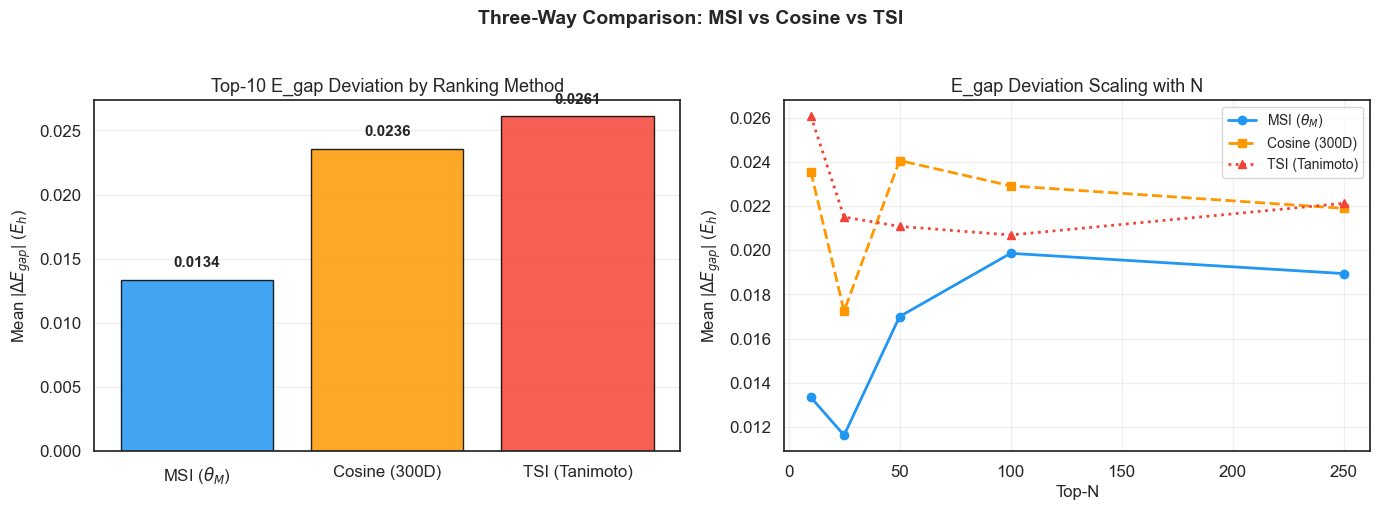

Top-10 overlap matrix:
  MSI n Cosine: 3/10
  MSI n TSI:    3/10
  Cosine n TSI: 6/10

Top-10 mean |delta E_gap|:
  MSI (theta_M): 0.0134 E_h
  Cosine (300D):  0.0236 E_h
  TSI (Tanimoto): 0.0261 E_h


,N,cosine_gap,msi_gap,tsi_gap
0,10,0.0236,0.0134,0.0261
1,25,0.0172,0.0116,0.0215
2,50,0.0241,0.0170,0.0211
3,100,0.0229,0.0199,0.0207
4,250,0.0219,0.0189,0.0221


In [26]:
# Compare cosine similarity (embedding_similarity) as a ranking metric
# embedding_similarity is already computed as cosine similarity in 300D space

# Top-10 by each metric
top_cosine = qm9_cands.nlargest(10, 'embedding_similarity')
top_theta = qm9_cands.nsmallest(10, 'theta')
top_tsi = qm9_cands.nlargest(10, 'tanimoto_similarity')

cos_gap = np.abs(top_cosine['gap'] - aniline_gap).mean()
msi_gap_val = np.abs(top_theta['gap'] - aniline_gap).mean()
tsi_gap_val = np.abs(top_tsi['gap'] - aniline_gap).mean()

# Overlap analysis
overlap_msi_cos = len(set(top_theta.index) & set(top_cosine.index))
overlap_tsi_cos = len(set(top_tsi.index) & set(top_cosine.index))
overlap_msi_tsi = len(set(top_theta.index) & set(top_tsi.index))

# Extended comparison at multiple N values
N_vals = [10, 25, 50, 100, 250]
cos_results = []
for N in N_vals:
    t_cos = qm9_cands.nlargest(N, 'embedding_similarity')
    t_msi = qm9_cands.nsmallest(N, 'theta')
    t_tsi = qm9_cands.nlargest(N, 'tanimoto_similarity')
    
    cos_results.append({
        'N': N,
        'cosine_gap': np.abs(t_cos['gap'] - aniline_gap).mean(),
        'msi_gap': np.abs(t_msi['gap'] - aniline_gap).mean(),
        'tsi_gap': np.abs(t_tsi['gap'] - aniline_gap).mean(),
    })

cos_df = pd.DataFrame(cos_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Bar comparison at N=10
ax = axes[0]
methods = ['MSI ($\\theta_M$)', 'Cosine (300D)', 'TSI (Tanimoto)']
values = [msi_gap_val, cos_gap, tsi_gap_val]
colors = ['#2196F3', '#FF9800', '#F44336']
bars = ax.bar(methods, values, color=colors, alpha=0.85, edgecolor='black')
ax.set_ylabel('Mean |$\\Delta E_{gap}$| ($E_h$)', fontsize=12)
ax.set_title('Top-10 E_gap Deviation by Ranking Method', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Panel 2: Scaling with N
ax = axes[1]
ax.plot(cos_df['N'], cos_df['msi_gap'], 'o-', color='#2196F3', lw=2, label='MSI ($\\theta_M$)')
ax.plot(cos_df['N'], cos_df['cosine_gap'], 's--', color='#FF9800', lw=2, label='Cosine (300D)')
ax.plot(cos_df['N'], cos_df['tsi_gap'], '^:', color='#F44336', lw=2, label='TSI (Tanimoto)')
ax.set_xlabel('Top-N', fontsize=12)
ax.set_ylabel('Mean |$\\Delta E_{gap}$| ($E_h$)', fontsize=12)
ax.set_title('E_gap Deviation Scaling with N', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Three-Way Comparison: MSI vs Cosine vs TSI',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Top-10 overlap matrix:')
print(f'  MSI n Cosine: {overlap_msi_cos}/10')
print(f'  MSI n TSI:    {overlap_msi_tsi}/10')
print(f'  Cosine n TSI: {overlap_tsi_cos}/10')
print(f'\nTop-10 mean |delta E_gap|:')
print(f'  MSI (theta_M): {msi_gap_val:.4f} E_h')
print(f'  Cosine (300D):  {cos_gap:.4f} E_h')
print(f'  TSI (Tanimoto): {tsi_gap_val:.4f} E_h')

display(cos_df.round(4))

---
### Extended 4: Metric Correlation Heatmap

How do all the similarity metrics correlate with each other? High correlation between $\theta_M$ and $d_M$ is expected (both are Mahalanobis-based), but the relationship with TSI and embedding cosine is more informative.

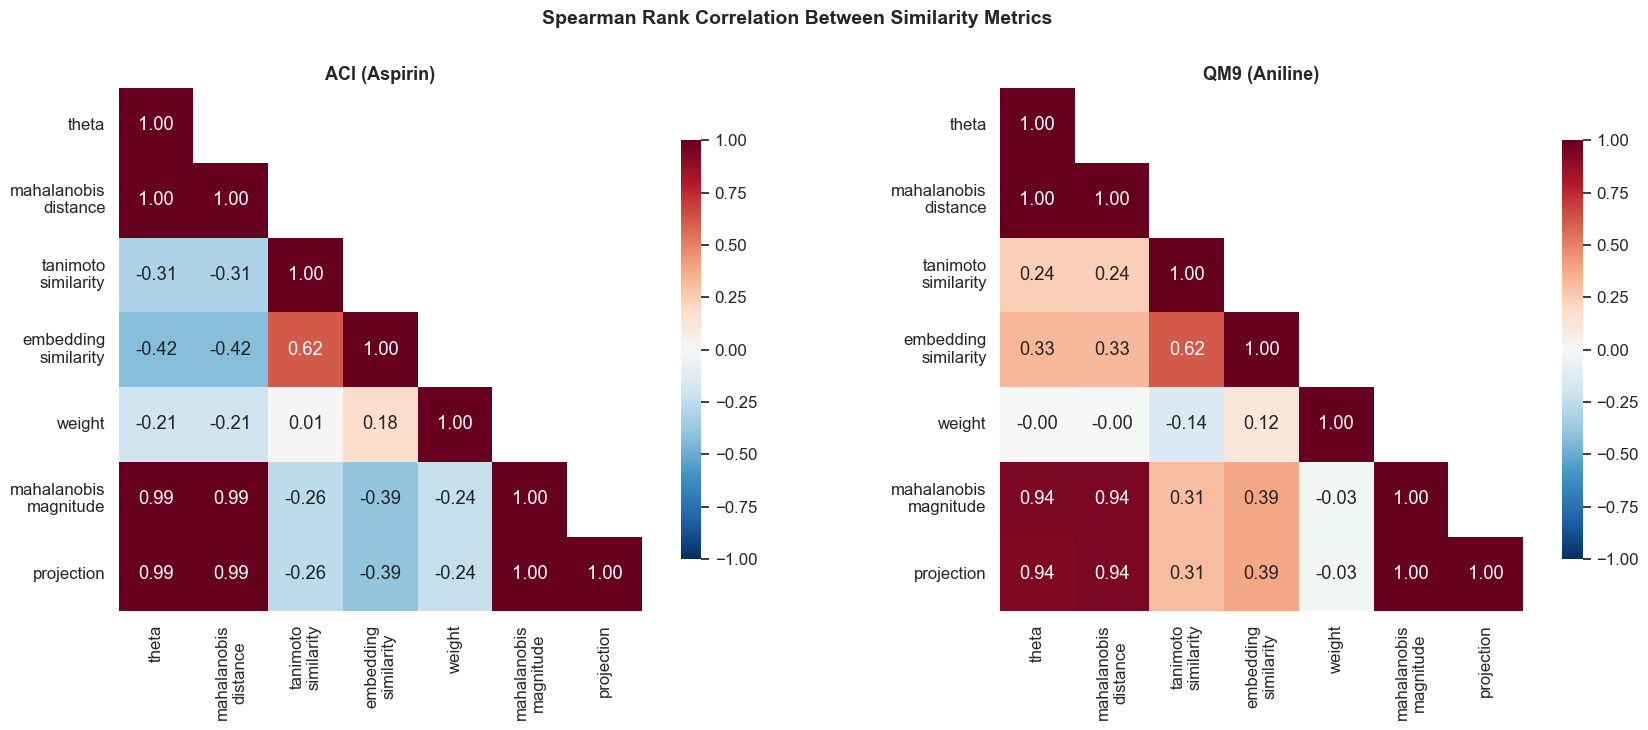


Aspirin:
  rho(theta, TSI)    = -0.3106
  rho(d_M, TSI)      = -0.3103
  rho(theta, d_M)    = 1.0000
  rho(cosine, theta) = -0.4234

Aniline/QM9:
  rho(theta, TSI)    = 0.2431
  rho(d_M, TSI)      = 0.2430
  rho(theta, d_M)    = 0.9976
  rho(cosine, theta) = 0.3284


In [27]:
# Correlation analysis across all metrics
metric_cols = ['theta', 'mahalanobis_distance', 'tanimoto_similarity', 
               'embedding_similarity', 'weight', 'mahalanobis_magnitude', 'projection']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, df) in zip(axes, [('ACI (Aspirin)', aspirin), ('QM9 (Aniline)', qm9)]):
    # Use rank correlation (Spearman) since relationships may be non-linear
    corr = df[metric_cols].corr(method='spearman')
    
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                xticklabels=[c.replace('_', '\n') for c in metric_cols],
                yticklabels=[c.replace('_', '\n') for c in metric_cols],
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

fig.suptitle('Spearman Rank Correlation Between Similarity Metrics',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print key correlations
for name, df in [('Aspirin', aspirin), ('Aniline/QM9', qm9)]:
    rho_theta_tsi = df['theta'].corr(df['tanimoto_similarity'], method='spearman')
    rho_dm_tsi = df['mahalanobis_distance'].corr(df['tanimoto_similarity'], method='spearman')
    rho_theta_dm = df['theta'].corr(df['mahalanobis_distance'], method='spearman')
    rho_cos_theta = df['embedding_similarity'].corr(df['theta'], method='spearman')
    print(f'\n{name}:')
    print(f'  rho(theta, TSI)    = {rho_theta_tsi:.4f}')
    print(f'  rho(d_M, TSI)      = {rho_dm_tsi:.4f}')
    print(f'  rho(theta, d_M)    = {rho_theta_dm:.4f}')
    print(f'  rho(cosine, theta) = {rho_cos_theta:.4f}')

---
### Extended 5: Distribution Shapes — $\theta_M$, $d_M$, and TSI

Understanding the marginal distributions helps characterize the chemical space coverage and identify where each metric has the most discriminative power.

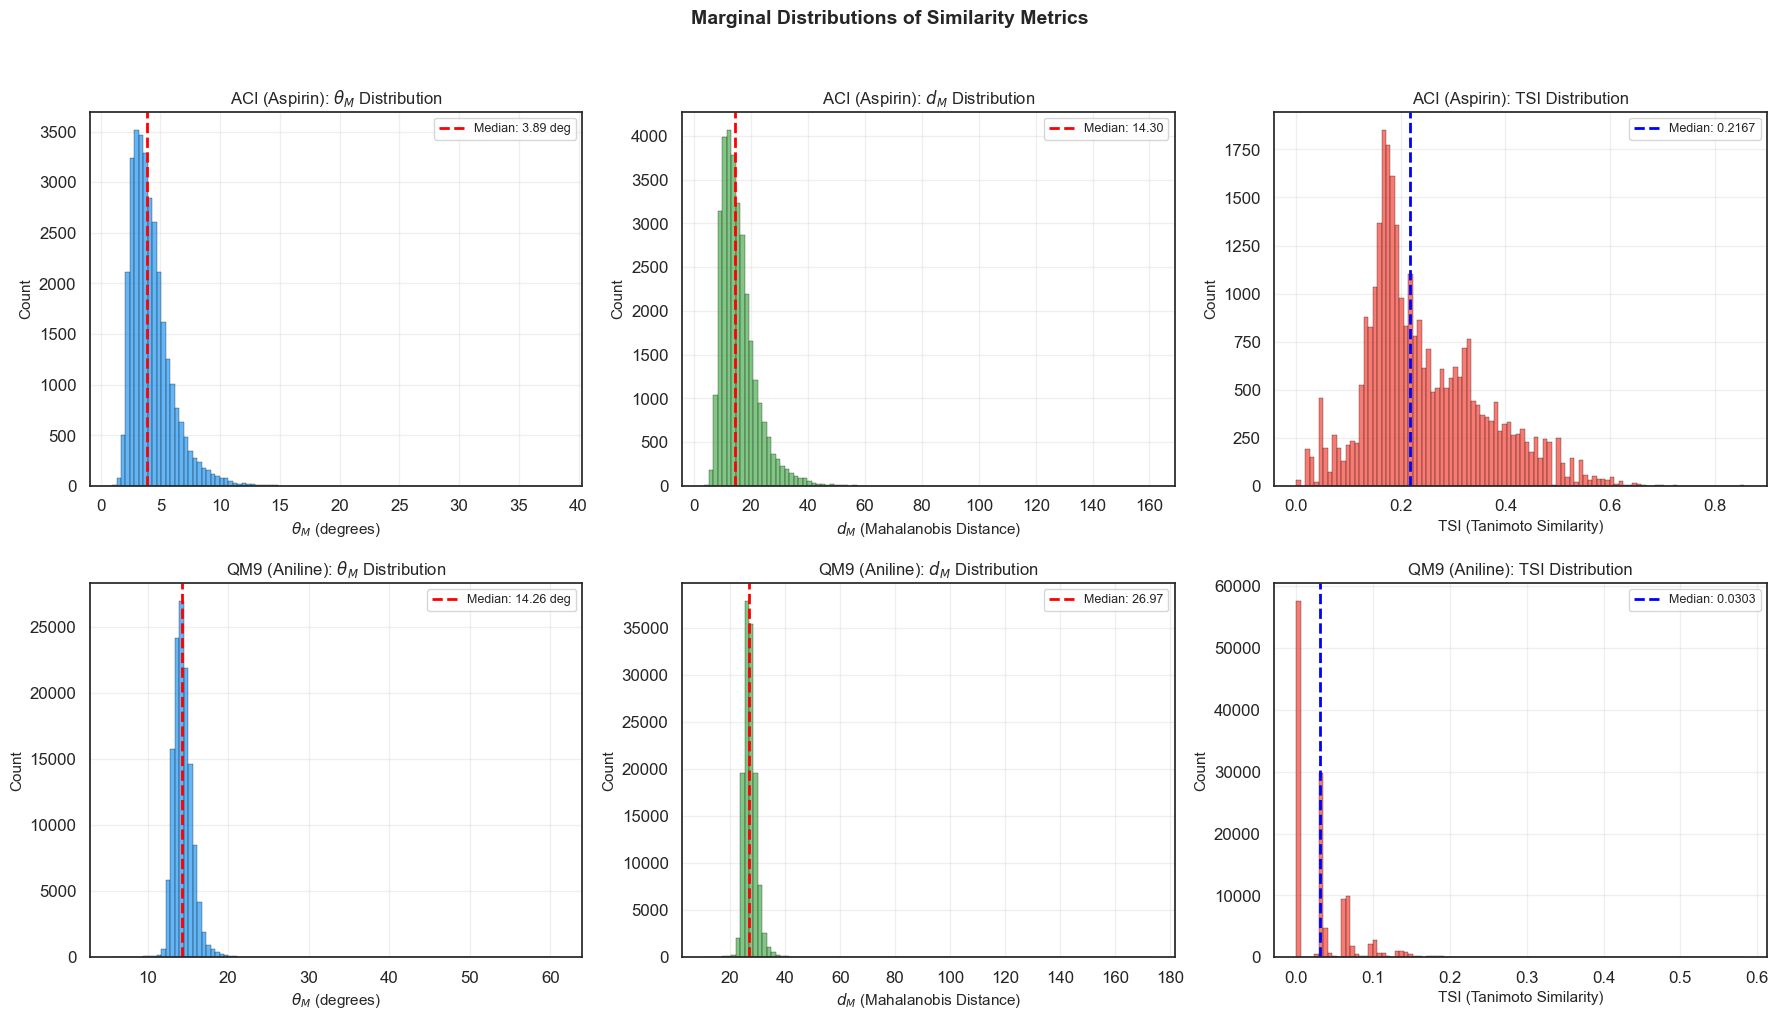


Aspirin (ACI) (N=31,392):
                      theta: mean=4.2685  std=1.7888  median=3.8870  skew=2.33  kurtosis=16.50
       mahalanobis_distance: mean=15.7332  std=6.6847  median=14.3028  skew=2.64  kurtosis=24.39
        tanimoto_similarity: mean=0.2460  std=0.1159  median=0.2167  skew=0.78  kurtosis=0.42

Aniline (QM9) (N=127,536):
                      theta: mean=14.3887  std=1.2547  median=14.2561  skew=2.23  kurtosis=38.61
       mahalanobis_distance: mean=27.2414  std=2.5141  median=26.9677  skew=4.39  kurtosis=168.22
        tanimoto_similarity: mean=0.0324  std=0.0404  median=0.0303  skew=1.83  kurtosis=5.65


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (name, df) in enumerate([('ACI (Aspirin)', aspirin), ('QM9 (Aniline)', qm9)]):
    cands = df.iloc[1:]  # exclude reference
    
    # theta distribution
    ax = axes[row, 0]
    ax.hist(cands['theta'], bins=100, alpha=0.7, color='#2196F3', edgecolor='black', linewidth=0.3)
    ax.axvline(cands['theta'].median(), color='red', lw=2, linestyle='--', 
               label=f'Median: {cands["theta"].median():.2f} deg')
    ax.set_xlabel('$\\theta_M$ (degrees)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}: $\\theta_M$ Distribution', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # d_M distribution
    ax = axes[row, 1]
    ax.hist(cands['mahalanobis_distance'], bins=100, alpha=0.7, color='#4CAF50', edgecolor='black', linewidth=0.3)
    ax.axvline(cands['mahalanobis_distance'].median(), color='red', lw=2, linestyle='--',
               label=f'Median: {cands["mahalanobis_distance"].median():.2f}')
    ax.set_xlabel('$d_M$ (Mahalanobis Distance)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}: $d_M$ Distribution', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # TSI distribution
    ax = axes[row, 2]
    ax.hist(cands['tanimoto_similarity'], bins=100, alpha=0.7, color='#F44336', edgecolor='black', linewidth=0.3)
    ax.axvline(cands['tanimoto_similarity'].median(), color='blue', lw=2, linestyle='--',
               label=f'Median: {cands["tanimoto_similarity"].median():.4f}')
    ax.set_xlabel('TSI (Tanimoto Similarity)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}: TSI Distribution', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Marginal Distributions of Similarity Metrics',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Descriptive stats table
for name, df in [('Aspirin (ACI)', aspirin), ('Aniline (QM9)', qm9)]:
    cands = df.iloc[1:]
    print(f'\n{name} (N={len(cands):,}):')
    for col in ['theta', 'mahalanobis_distance', 'tanimoto_similarity']:
        s = cands[col]
        print(f'  {col:>25s}: mean={s.mean():.4f}  std={s.std():.4f}  '
              f'median={s.median():.4f}  skew={s.skew():.2f}  kurtosis={s.kurtosis():.2f}')

---
### Extended 6: QM9 — Does Mahalanobis Proximity Predict Multiple Quantum Properties?

We've shown MSI outperforms TSI for $E_{gap}$. But does this generalize to other quantum-chemical properties (HOMO, LUMO, dipole moment $\mu$, polarizability $\alpha$)?

For each property, we measure the mean absolute deviation of the top-50 molecules (by each ranking method) from the aniline reference value.

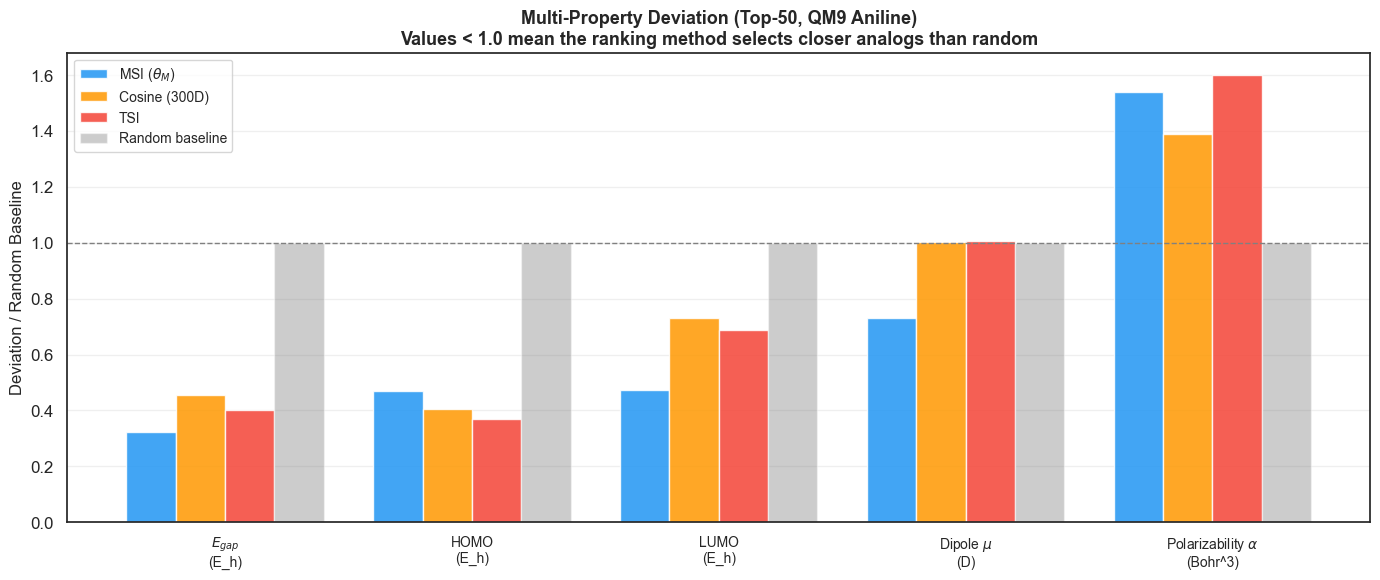

Top-50 multi-property analysis (normalized by random baseline):


,property,unit,ref_value,MSI_dev,Cosine_dev,TSI_dev,Random_dev,best
0,$E_{gap}$,E_h,0.2077,0.0170,0.0241,0.0211,0.0527,MSI
1,HOMO,E_h,-0.1991,0.0197,0.0170,0.0154,0.0419,TSI
2,LUMO,E_h,0.0086,0.0183,0.0283,0.0267,0.0388,MSI
3,Dipole $\mu$,D,1.6318,0.9870,1.3536,1.3562,1.3488,MSI
4,Polarizability $\alpha$,Bohr^3,67.3000,14.6910,13.2706,15.2680,9.5412,Cosine


In [29]:
# QM9 multi-property analysis
properties = {
    'gap': ('$E_{gap}$', 'E_h'),
    'homo': ('HOMO', 'E_h'),
    'lumo': ('LUMO', 'E_h'),
    'mu': ('Dipole $\\mu$', 'D'),
    'alpha': ('Polarizability $\\alpha$', 'Bohr^3'),
}

N_MULTI = 50
ref_vals = {prop: qm9[prop].iloc[0] for prop in properties}

multi_results = []
for prop, (label, unit) in properties.items():
    top_msi_p = qm9_cands.nsmallest(N_MULTI, 'theta')
    top_cos_p = qm9_cands.nlargest(N_MULTI, 'embedding_similarity')
    top_tsi_p = qm9_cands.nlargest(N_MULTI, 'tanimoto_similarity')
    
    ref = ref_vals[prop]
    msi_dev = np.abs(top_msi_p[prop] - ref).mean()
    cos_dev = np.abs(top_cos_p[prop] - ref).mean()
    tsi_dev = np.abs(top_tsi_p[prop] - ref).mean()
    all_dev = np.abs(qm9_cands[prop] - ref).mean()
    
    multi_results.append({
        'property': label, 'unit': unit,
        'ref_value': ref,
        'MSI_dev': msi_dev, 'Cosine_dev': cos_dev, 'TSI_dev': tsi_dev,
        'Random_dev': all_dev,
        'MSI_vs_random': msi_dev / all_dev,
        'best': 'MSI' if msi_dev <= min(cos_dev, tsi_dev) else ('Cosine' if cos_dev <= tsi_dev else 'TSI'),
    })

multi_df = pd.DataFrame(multi_results)

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(properties))
w = 0.2

bars1 = ax.bar(x - 1.5*w, multi_df['MSI_dev'] / multi_df['Random_dev'], w, 
               color='#2196F3', alpha=0.85, label='MSI ($\\theta_M$)')
bars2 = ax.bar(x - 0.5*w, multi_df['Cosine_dev'] / multi_df['Random_dev'], w,
               color='#FF9800', alpha=0.85, label='Cosine (300D)')
bars3 = ax.bar(x + 0.5*w, multi_df['TSI_dev'] / multi_df['Random_dev'], w,
               color='#F44336', alpha=0.85, label='TSI')
ax.bar(x + 1.5*w, [1.0]*len(properties), w, color='gray', alpha=0.4, label='Random baseline')

ax.axhline(y=1.0, color='gray', linestyle='--', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f'{r["property"]}\n({r["unit"]})' for _, r in multi_df.iterrows()], fontsize=10)
ax.set_ylabel('Deviation / Random Baseline', fontsize=12)
ax.set_title(f'Multi-Property Deviation (Top-{N_MULTI}, QM9 Aniline)\n'
             f'Values < 1.0 mean the ranking method selects closer analogs than random',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Top-{N_MULTI} multi-property analysis (normalized by random baseline):')
display(multi_df[['property', 'unit', 'ref_value', 'MSI_dev', 'Cosine_dev', 'TSI_dev', 'Random_dev', 'best']].round(4))

---
### Extended 7: Sensitivity to Regularization Parameter $\lambda$

The covariance matrix is regularized with $\lambda = 10^{-5}$. How sensitive are the top-10 rankings to this choice? We recompute theta for several $\lambda$ values and measure rank stability via Spearman correlation.

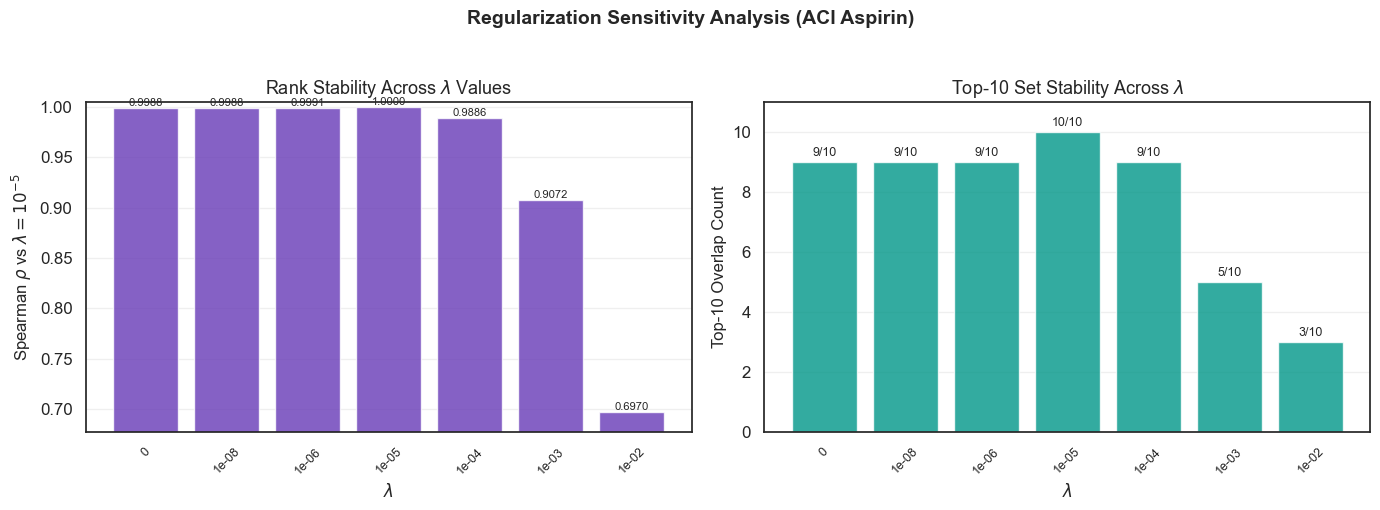

Condition numbers by lambda:
  lambda=0: cond=1.81e+04
  lambda=1e-08: cond=1.81e+04
  lambda=1e-06: cond=1.62e+04
  lambda=1e-05: cond=8.20e+03
  lambda=1e-04: cond=1.38e+03
  lambda=1e-03: cond=1.49e+02
  lambda=1e-02: cond=1.59e+01


In [30]:
# Load the 300D vectors for recomputation
from scipy.stats import spearmanr

vec_300d = pd.read_csv(aspirin_300d_path).values
ref_vec = vec_300d[0]

lambdas = [0, 1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
theta_by_lambda = {}

cov_raw = np.cov(vec_300d.T)

for lam in lambdas:
    cov_reg = cov_raw + np.eye(cov_raw.shape[0]) * lam
    try:
        inv_cov = np.linalg.inv(cov_reg)
    except np.linalg.LinAlgError:
        print(f'lambda={lam}: Singular matrix, skipping')
        continue
    
    # Vectorized theta computation
    numerator = vec_300d @ inv_cov @ ref_vec
    vi_norms = np.sqrt(np.maximum(np.einsum('ij,ij->i', vec_300d, vec_300d @ inv_cov), 0))
    vref_norm = np.sqrt(max(ref_vec @ inv_cov @ ref_vec, 0))
    denom = vi_norms * vref_norm
    safe_denom = np.where(denom == 0, 1.0, denom)
    cos_vals = np.clip(numerator / safe_denom, -1, 1)
    theta_vals = np.degrees(np.arccos(cos_vals))
    theta_vals = np.where(denom == 0, 0.0, theta_vals)
    
    theta_by_lambda[lam] = theta_vals

# Rank correlation between different lambda values
ref_lambda = 1e-5
ref_ranks = theta_by_lambda[ref_lambda]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Spearman correlation with reference lambda
ax = axes[0]
correlations = []
for lam in lambdas:
    if lam in theta_by_lambda:
        rho, _ = spearmanr(ref_ranks, theta_by_lambda[lam])
        correlations.append((lam, rho))

lam_labels = [f'{l:.0e}' if l > 0 else '0' for l, _ in correlations]
rho_vals = [r for _, r in correlations]

ax.bar(range(len(correlations)), rho_vals, color='#673AB7', alpha=0.8)
ax.set_xticks(range(len(correlations)))
ax.set_xticklabels(lam_labels, rotation=45, fontsize=9)
ax.set_xlabel('$\\lambda$', fontsize=12)
ax.set_ylabel('Spearman $\\rho$ vs $\\lambda=10^{-5}$', fontsize=12)
ax.set_title('Rank Stability Across $\\lambda$ Values', fontsize=13)
ax.set_ylim(min(0.9, min(rho_vals) - 0.02), 1.005)
ax.grid(True, alpha=0.3, axis='y')
for i, r in enumerate(rho_vals):
    ax.text(i, r + 0.002, f'{r:.4f}', ha='center', fontsize=8)

# Panel 2: Top-10 stability
ax = axes[1]
top10_ref = set(np.argsort(ref_ranks)[1:11])  # skip index 0 (reference)
stability = []
for lam in lambdas:
    if lam in theta_by_lambda:
        top10_lam = set(np.argsort(theta_by_lambda[lam])[1:11])
        jaccard = len(top10_ref & top10_lam) / len(top10_ref | top10_lam)
        overlap_n = len(top10_ref & top10_lam)
        stability.append((lam, overlap_n, jaccard))

lam_labels2 = [f'{l:.0e}' if l > 0 else '0' for l, _, _ in stability]
overlaps = [o for _, o, _ in stability]

ax.bar(range(len(stability)), overlaps, color='#009688', alpha=0.8)
ax.set_xticks(range(len(stability)))
ax.set_xticklabels(lam_labels2, rotation=45, fontsize=9)
ax.set_xlabel('$\\lambda$', fontsize=12)
ax.set_ylabel('Top-10 Overlap Count', fontsize=12)
ax.set_title('Top-10 Set Stability Across $\\lambda$', fontsize=13)
ax.set_ylim(0, 11)
ax.grid(True, alpha=0.3, axis='y')
for i, o in enumerate(overlaps):
    ax.text(i, o + 0.2, f'{o}/10', ha='center', fontsize=9)

fig.suptitle('Regularization Sensitivity Analysis (ACI Aspirin)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Condition numbers
print('Condition numbers by lambda:')
for lam in lambdas:
    cov_test = cov_raw + np.eye(cov_raw.shape[0]) * lam
    cond = np.linalg.cond(cov_test)
    if lam > 0:
        print(f'  lambda={lam:.0e}: cond={cond:.2e}')
    else:
        print(f'  lambda=0: cond={cond:.2e}')

---
### Extended 8: t-SNE Embedding Space — Chemical Landscape

Visualize the 2D t-SNE projection colored by each metric. This reveals whether high-similarity regions cluster spatially or are dispersed across the embedding.

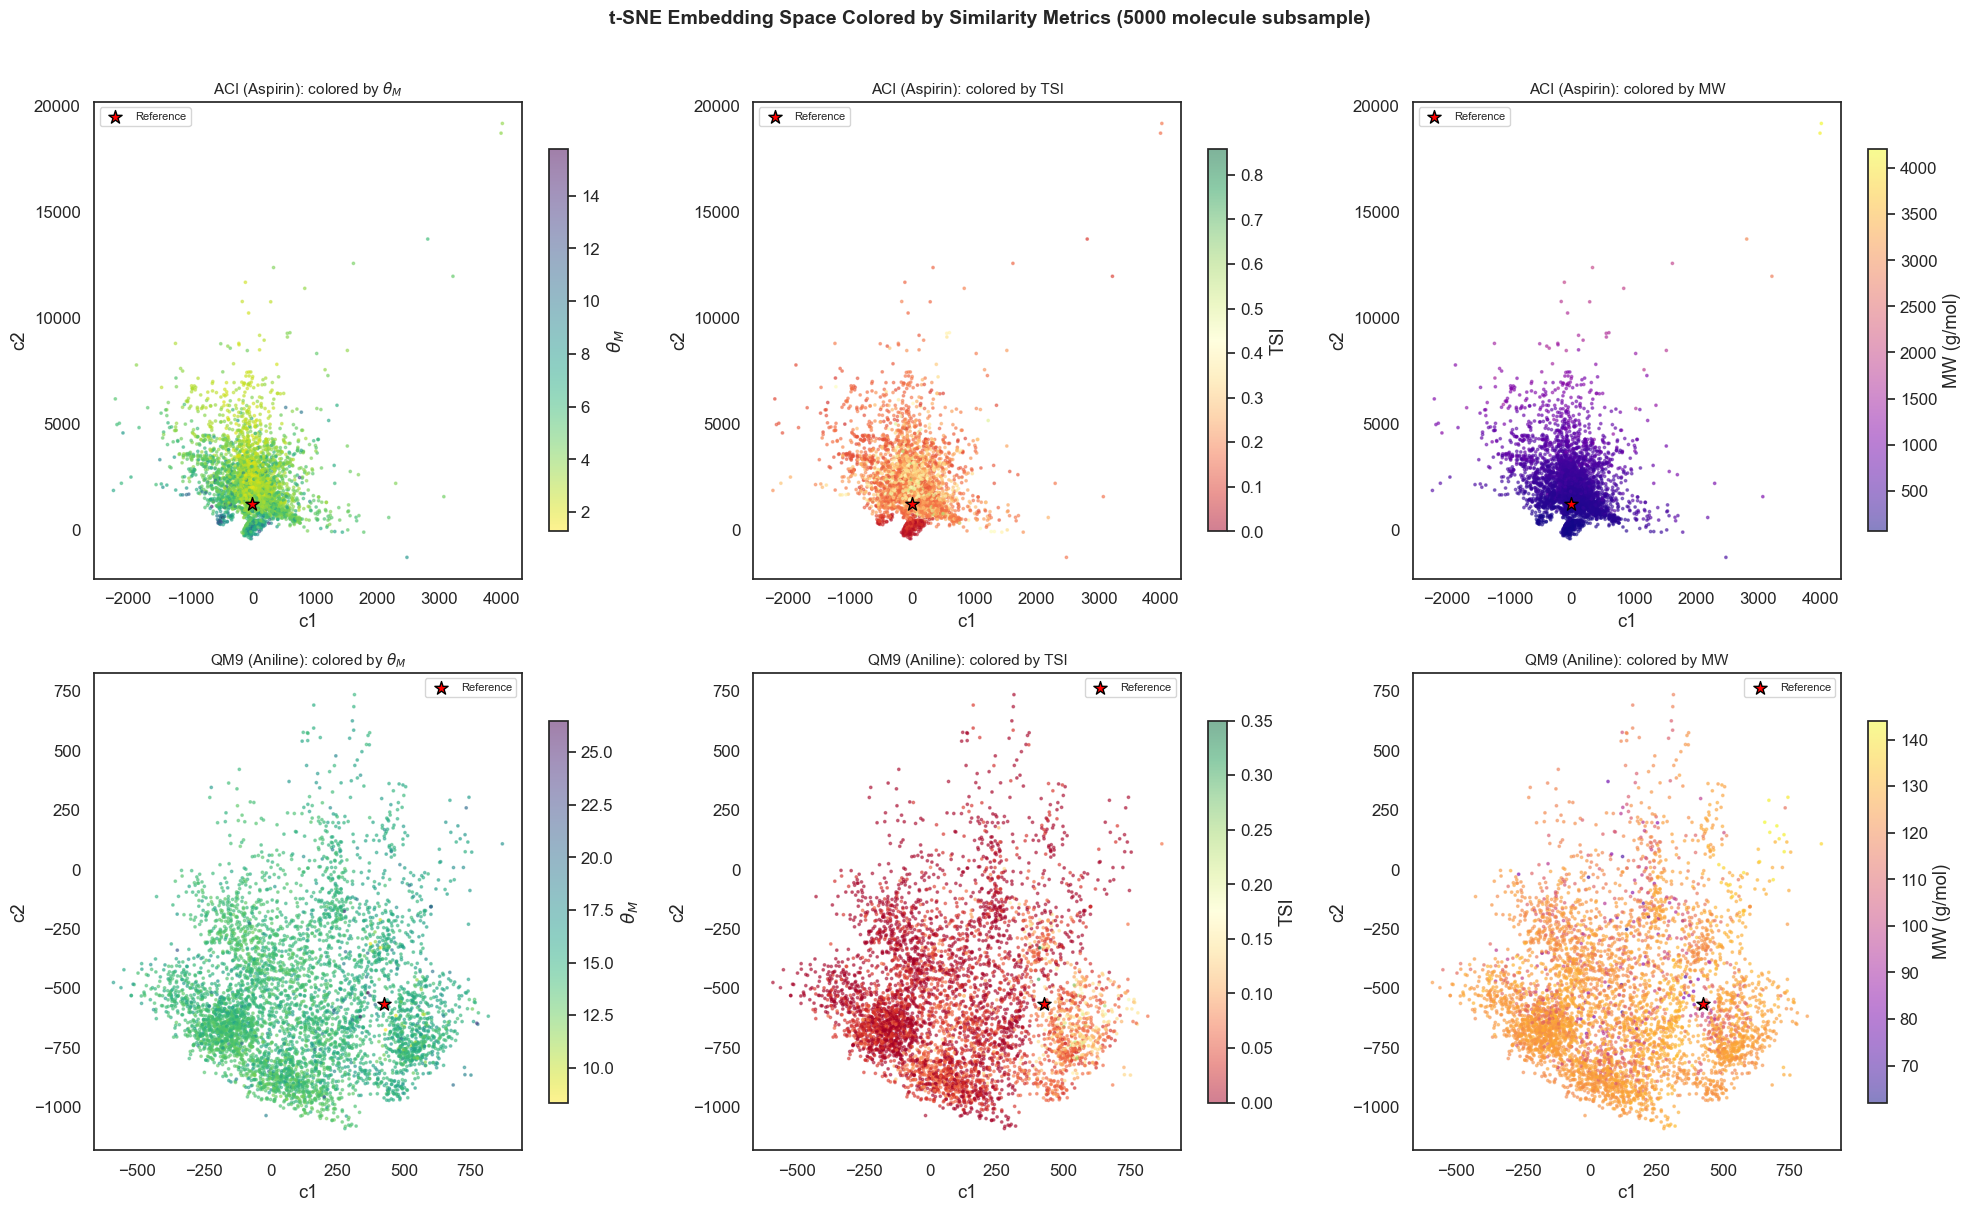

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row, (name, df) in enumerate([('ACI (Aspirin)', aspirin), ('QM9 (Aniline)', qm9)]):
    sample_df = df.sample(min(5000, len(df)), random_state=42)
    
    # Panel 1: colored by theta
    ax = axes[row, 0]
    sc = ax.scatter(sample_df['c1'], sample_df['c2'], c=sample_df['theta'],
                    cmap='viridis_r', alpha=0.5, s=3, rasterized=True)
    ax.scatter(df['c1'].iloc[0], df['c2'].iloc[0], color='red', s=100, marker='*',
               edgecolors='black', zorder=5, label='Reference')
    ax.set_title(f'{name}: colored by $\\theta_M$', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='$\\theta_M$', shrink=0.8)
    ax.set_xlabel('c1'); ax.set_ylabel('c2')
    
    # Panel 2: colored by TSI
    ax = axes[row, 1]
    sc = ax.scatter(sample_df['c1'], sample_df['c2'], c=sample_df['tanimoto_similarity'],
                    cmap='RdYlGn', alpha=0.5, s=3, rasterized=True)
    ax.scatter(df['c1'].iloc[0], df['c2'].iloc[0], color='red', s=100, marker='*',
               edgecolors='black', zorder=5, label='Reference')
    ax.set_title(f'{name}: colored by TSI', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='TSI', shrink=0.8)
    ax.set_xlabel('c1'); ax.set_ylabel('c2')
    
    # Panel 3: colored by MW
    ax = axes[row, 2]
    sc = ax.scatter(sample_df['c1'], sample_df['c2'], c=sample_df['weight'],
                    cmap='plasma', alpha=0.5, s=3, rasterized=True)
    ax.scatter(df['c1'].iloc[0], df['c2'].iloc[0], color='red', s=100, marker='*',
               edgecolors='black', zorder=5, label='Reference')
    ax.set_title(f'{name}: colored by MW', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='MW (g/mol)', shrink=0.8)
    ax.set_xlabel('c1'); ax.set_ylabel('c2')

fig.suptitle('t-SNE Embedding Space Colored by Similarity Metrics (5000 molecule subsample)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
### Extended 8b: t-SNE Embedding Space (4x Ref)

Same visualization as Extended 8, but filtering molecules that weigh more than 4 times the molecular weight of the reference molecule. This removes extremely large molecules that distort the color scale and obscure local patterns in the embedding space.

Aspirin: MW = 180.16 g/mol → filter: MW ≤ 720.64 g/mol

Aniline: MW = 93.13 g/mol → filter: MW ≤ 372.52 g/mol


ACI (Aspirin): ref MW=180.16, filter MW<=720.64, kept 28,364/31,393 (90.4%), removed 3,029 heavy molecules
QM9 (Aniline): ref MW=93.13, filter MW<=372.52, kept 127,537/127,537 (100.0%), removed 0 heavy molecules


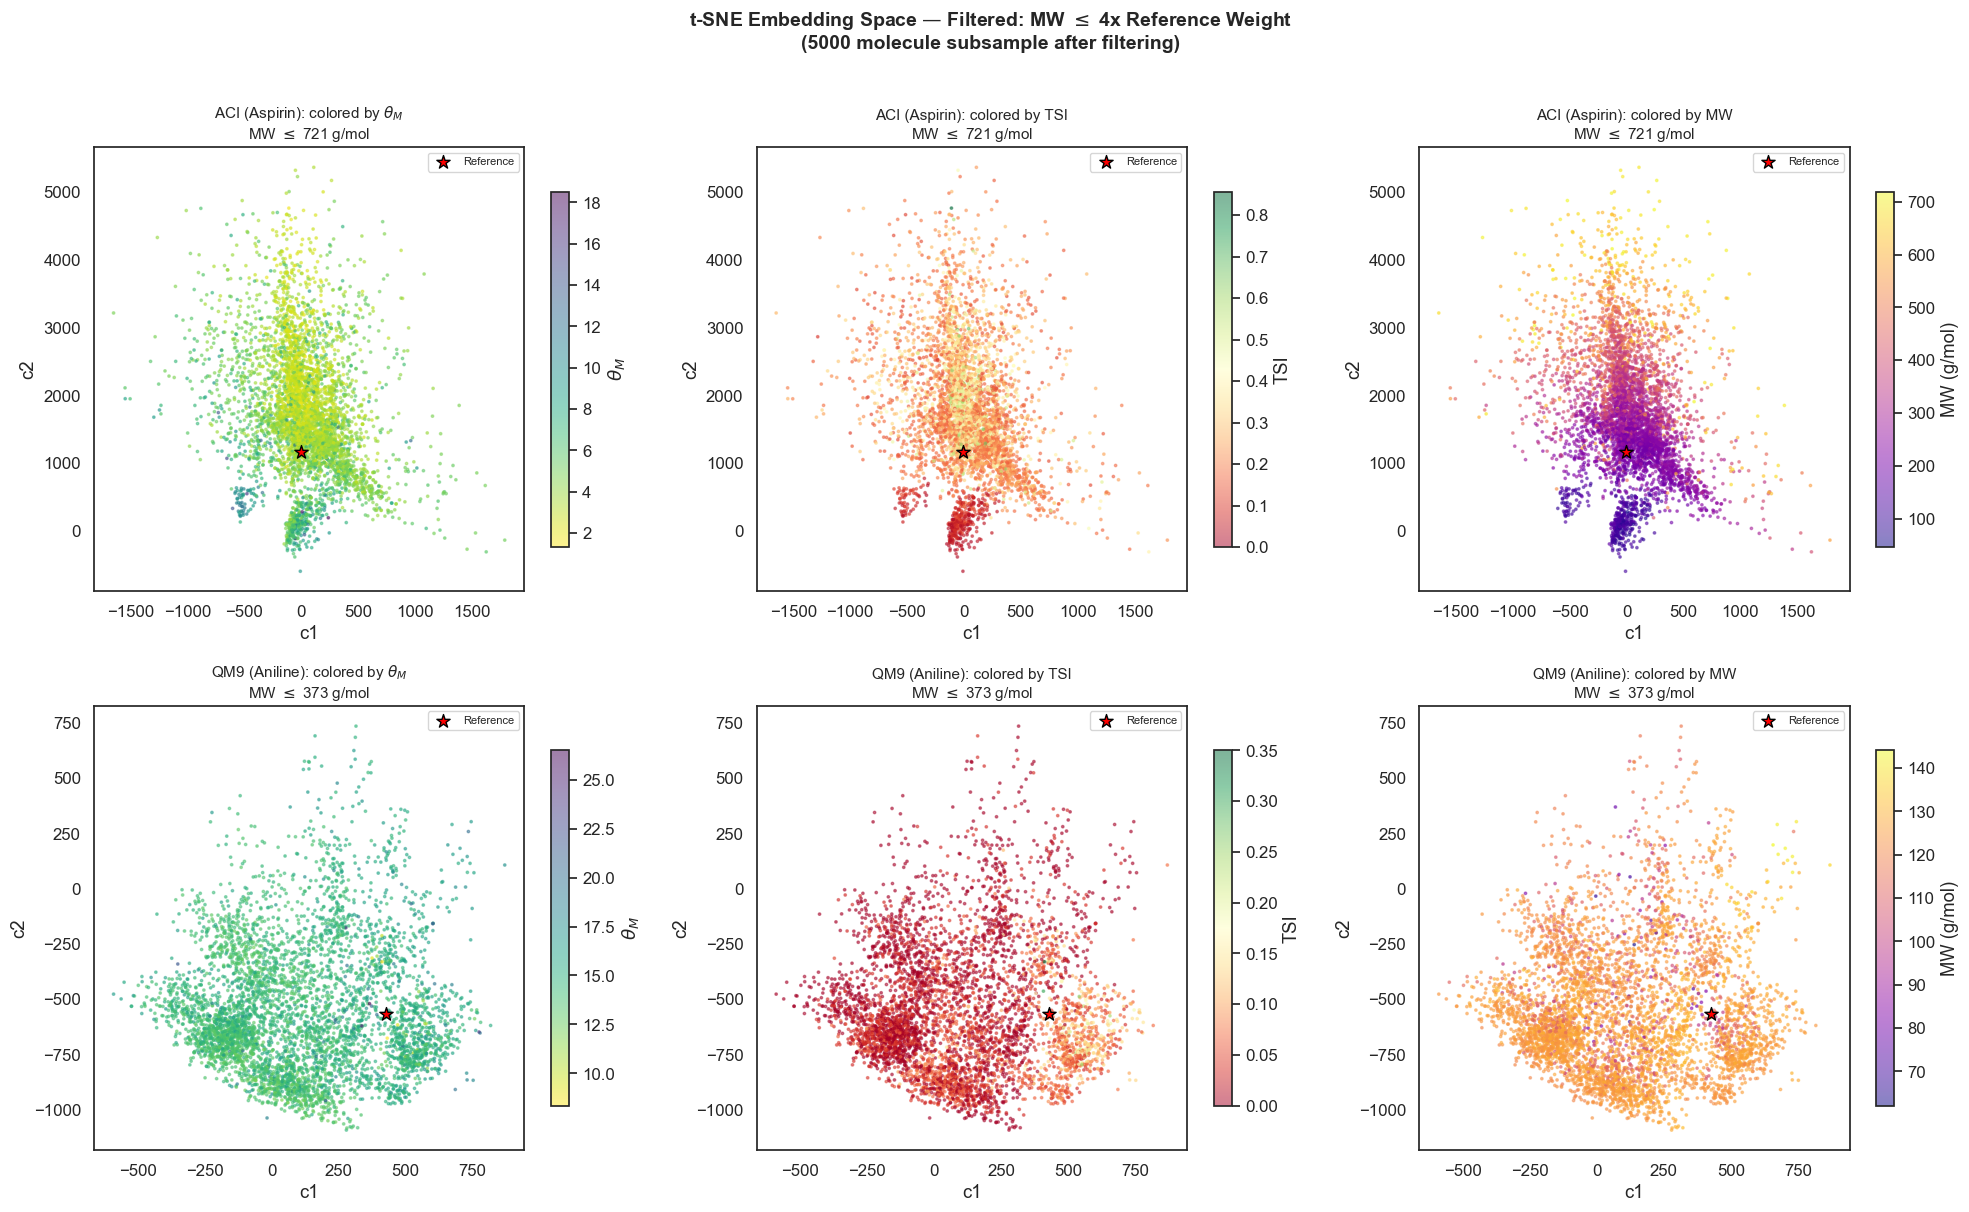

In [32]:
# Extended 8b: t-SNE with weight filter (remove molecules > 4x reference weight)
ref_weights = {
    'ACI (Aspirin)': aspirin['weight'].iloc[0],
    'QM9 (Aniline)': qm9['weight'].iloc[0],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row, (name, df) in enumerate([('ACI (Aspirin)', aspirin), ('QM9 (Aniline)', qm9)]):
    ref_w = ref_weights[name]
    max_w = 4 * ref_w
    df_filtered = df[df['weight'] <= max_w]
    n_removed = len(df) - len(df_filtered)
    print(f'{name}: ref MW={ref_w:.2f}, filter MW<={max_w:.2f}, '
          f'kept {len(df_filtered):,}/{len(df):,} ({100*len(df_filtered)/len(df):.1f}%), '
          f'removed {n_removed:,} heavy molecules')
    
    sample_df = df_filtered.sample(min(5000, len(df_filtered)), random_state=42)
    
    # Panel 1: colored by theta
    ax = axes[row, 0]
    sc = ax.scatter(sample_df['c1'], sample_df['c2'], c=sample_df['theta'],
                    cmap='viridis_r', alpha=0.5, s=3, rasterized=True)
    ax.scatter(df['c1'].iloc[0], df['c2'].iloc[0], color='red', s=100, marker='*',
               edgecolors='black', zorder=5, label='Reference')
    ax.set_title(f'{name}: colored by $\\theta_M$\nMW $\\leq$ {max_w:.0f} g/mol', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='$\\theta_M$', shrink=0.8)
    ax.set_xlabel('c1'); ax.set_ylabel('c2')
    
    # Panel 2: colored by TSI
    ax = axes[row, 1]
    sc = ax.scatter(sample_df['c1'], sample_df['c2'], c=sample_df['tanimoto_similarity'],
                    cmap='RdYlGn', alpha=0.5, s=3, rasterized=True)
    ax.scatter(df['c1'].iloc[0], df['c2'].iloc[0], color='red', s=100, marker='*',
               edgecolors='black', zorder=5, label='Reference')
    ax.set_title(f'{name}: colored by TSI\nMW $\\leq$ {max_w:.0f} g/mol', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='TSI', shrink=0.8)
    ax.set_xlabel('c1'); ax.set_ylabel('c2')
    
    # Panel 3: colored by MW
    ax = axes[row, 2]
    sc = ax.scatter(sample_df['c1'], sample_df['c2'], c=sample_df['weight'],
                    cmap='plasma', alpha=0.5, s=3, rasterized=True)
    ax.scatter(df['c1'].iloc[0], df['c2'].iloc[0], color='red', s=100, marker='*',
               edgecolors='black', zorder=5, label='Reference')
    ax.set_title(f'{name}: colored by MW\nMW $\\leq$ {max_w:.0f} g/mol', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='MW (g/mol)', shrink=0.8)
    ax.set_xlabel('c1'); ax.set_ylabel('c2')

fig.suptitle('t-SNE Embedding Space — Filtered: MW $\\leq$ 4x Reference Weight\n'
             '(5000 molecule subsample after filtering)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
### Extended 9: Cross-Reference Theta Consistency

If MSI rankings are meaningful, the same molecule should have a consistently low theta across different reference molecules. We check: do aspirin's top analogs also rank well when using ibuprofen or curcumin as reference?

Merged dataset: 31,390 molecules with all three references


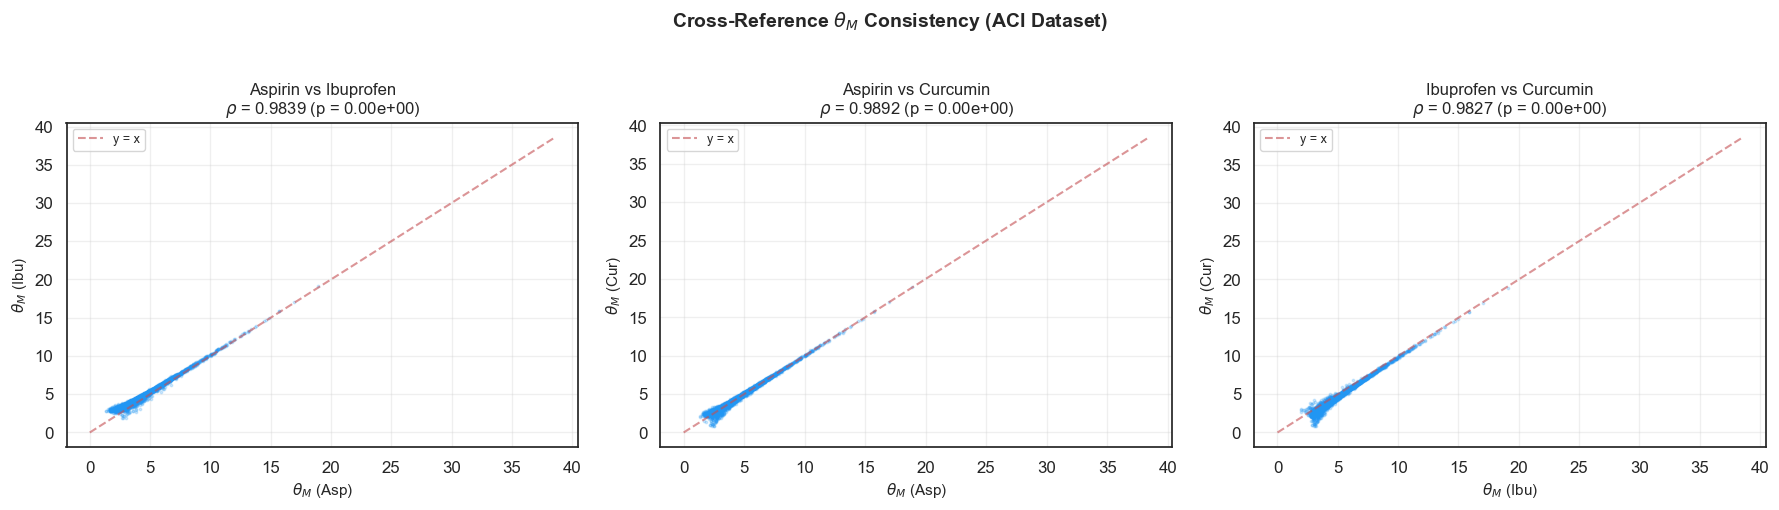


Top-10 "universally similar" molecules (lowest max theta across all 3 references):


,smiles,theta_asp,theta_ibu,theta_cur,mean_theta,max_theta
20950,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC2=C(C=C(C=C2)C=C...,2.203,2.121,1.386,1.904,2.203
20884,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC2=C(C=C(C=C2)C=C...,2.451,1.919,2.067,2.146,2.451
13458,CC(C)CCOC1=CC=C(C=C1)C(=O)OC2=CC=CC=C2C(=O)O,1.997,2.453,2.305,2.252,2.453
13413,CC(C)CCOC1=CC=CC=C1C(=O)OC2=CC=CC=C2C(=O)O,1.947,2.491,2.331,2.256,2.491
5899,CC(C)CCCC1=CC(=C(C=C1)C(=O)O)OC(=O)C(C)C2=CC=C...,2.172,2.317,2.501,2.330,2.501
13310,CC(C)CCOC1=CC=CC(=C1)C(=O)OC2=CC=CC=C2C(=O)O,2.034,2.507,2.335,2.292,2.507
9493,CCCCCCOC1=CC=CC(=C1OC(=O)C2=CC=CC=C2)C(=O)OCCC...,2.218,2.511,2.263,2.331,2.511
2822,CC(C)CC1=CC=C(C=C1)C(C)C(=O)OC2=CC=CC=C2C(=O)OC,2.378,1.756,2.518,2.217,2.518
12436,CC(C)CCOC1=CC=C(C=C1)C(=O)OC2=CC=CC=C2C(=O)OC,2.281,2.528,2.345,2.384,2.528
16644,CC(C)CCCCCOC1=CC=CC=C1C(=O)O,2.187,2.537,2.522,2.415,2.537


In [33]:
# Merge aspirin, ibuprofen, curcumin results by SMILES
from scipy.stats import spearmanr

asp_cands = aspirin.iloc[1:][['smiles', 'theta', 'tanimoto_similarity']].rename(
    columns={'theta': 'theta_asp', 'tanimoto_similarity': 'tsi_asp'})
ibu_cands = ibuprofen.iloc[1:][['smiles', 'theta', 'tanimoto_similarity']].rename(
    columns={'theta': 'theta_ibu', 'tanimoto_similarity': 'tsi_ibu'})
cur_cands = curcumin.iloc[1:][['smiles', 'theta', 'tanimoto_similarity']].rename(
    columns={'theta': 'theta_cur', 'tanimoto_similarity': 'tsi_cur'})

merged = asp_cands.merge(ibu_cands, on='smiles', how='inner').merge(cur_cands, on='smiles', how='inner')
print(f'Merged dataset: {len(merged):,} molecules with all three references')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('theta_asp', 'theta_ibu', 'Aspirin vs Ibuprofen'),
    ('theta_asp', 'theta_cur', 'Aspirin vs Curcumin'),
    ('theta_ibu', 'theta_cur', 'Ibuprofen vs Curcumin'),
]

for ax, (col_x, col_y, title) in zip(axes, pairs):
    sample_m = merged.sample(min(5000, len(merged)), random_state=42)
    ax.scatter(sample_m[col_x], sample_m[col_y], alpha=0.2, s=3, c='#2196F3', rasterized=True)
    
    rho, pval = spearmanr(merged[col_x], merged[col_y])
    
    # Add diagonal
    lims = [0, max(merged[col_x].max(), merged[col_y].max())]
    ax.plot(lims, lims, 'r--', lw=1.5, alpha=0.6, label='y = x')
    
    ax.set_xlabel(f'$\\theta_M$ ({col_x.split("_")[1].title()})', fontsize=11)
    ax.set_ylabel(f'$\\theta_M$ ({col_y.split("_")[1].title()})', fontsize=11)
    ax.set_title(f'{title}\n$\\rho$ = {rho:.4f} (p = {pval:.2e})', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Cross-Reference $\\theta_M$ Consistency (ACI Dataset)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Identify molecules that rank well across all three
merged['mean_theta'] = merged[['theta_asp', 'theta_ibu', 'theta_cur']].mean(axis=1)
merged['max_theta'] = merged[['theta_asp', 'theta_ibu', 'theta_cur']].max(axis=1)
universal_top10 = merged.nsmallest(10, 'max_theta')

print(f'\nTop-10 "universally similar" molecules (lowest max theta across all 3 references):')
display(universal_top10[['smiles', 'theta_asp', 'theta_ibu', 'theta_cur', 'mean_theta', 'max_theta']].round(3))